In [6]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

# Set path ke folder EEGdenoiseNet
base_path = r"C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV"
print(f"Mengakses folder: {base_path}")

# Cek isi folder EEGdenoiseNet
try:
    files_in_folder = os.listdir(base_path)
    print("\nFile dalam folder EEGdenoiseNet:")
    for file in files_in_folder:
        print(f"  {file}")
    
    # Cari file BCI Competition
    bci_files = [f for f in files_in_folder if 'comp' in f.lower() and f.endswith('.mat')]
    print(f"\nFile BCI Competition yang ditemukan: {bci_files}")
    
except FileNotFoundError:
    print(f"Folder {base_path} tidak ditemukan!")
    # Fallback ke direktori current
    print("File dalam direktori current:", os.listdir())

Mengakses folder: C:\Users\akip\Desktop\EEGdenoiseNet\Data BCI Competition IV

File dalam folder EEGdenoiseNet:
  sub1_comp.mat
  sub2_comp.mat
  sub3_comp.mat

File BCI Competition yang ditemukan: ['sub1_comp.mat', 'sub2_comp.mat', 'sub3_comp.mat']


In [7]:
# Load file BCI Competition yang tersedia
loaded_bci_data = {}

if bci_files:
    for bci_file in bci_files:
        try:
            file_path = os.path.join(base_path, bci_file)
            loaded_bci_data[bci_file] = scipy.io.loadmat(file_path)
            print(f"✓ Berhasil load: {bci_file}")
            
            # Tampilkan struktur data
            for key in loaded_bci_data[bci_file].keys():
                if not key.startswith('__'):
                    data_content = loaded_bci_data[bci_file][key]
                    if isinstance(data_content, np.ndarray):
                        print(f"  Key: {key}, Shape: {data_content.shape}, Type: {data_content.dtype}")
                    else:
                        print(f"  Key: {key}, Content: {data_content}")
                        
        except Exception as e:
            print(f"✗ Gagal load {bci_file}: {e}")
else:
    print("Tidak ada file BCI Competition ditemukan!")
    # Cari file .mat lainnya
    mat_files = [f for f in files_in_folder if f.endswith('.mat')]
    print(f"File .mat lainnya: {mat_files}")

✓ Berhasil load: sub1_comp.mat
  Key: train_data, Shape: (400000, 62), Type: int32
  Key: test_data, Shape: (200000, 62), Type: int16
  Key: train_dg, Shape: (400000, 5), Type: float64
✓ Berhasil load: sub2_comp.mat
  Key: train_data, Shape: (400000, 48), Type: int32
  Key: test_data, Shape: (200000, 48), Type: int32
  Key: train_dg, Shape: (400000, 5), Type: float64
✓ Berhasil load: sub3_comp.mat
  Key: train_data, Shape: (400000, 64), Type: int16
  Key: test_data, Shape: (200000, 64), Type: int32
  Key: train_dg, Shape: (400000, 5), Type: float64


In [8]:
def analyze_bci_artifacts(data_dict, file_name):
    """
    Analisis artefak untuk data BCI Competition
    """
    print(f"\n{'='*60}")
    print(f"ARTEFAK ANALYSIS: {file_name}")
    print(f"{'='*60}")
    
    for key, value in data_dict.items():
        if not key.startswith('__') and isinstance(value, np.ndarray):
            print(f"\nAnalysing array: {key} (shape: {value.shape})")
            
            # Handle berbagai kemungkinan struktur data BCI Competition
            if value.ndim == 2:
                # Asumsi format [channels, time] atau [trials, channels, time] yang di-flatten
                if value.shape[0] < value.shape[1]:  # [channels, time]
                    eeg_data = value
                else:  # [time, channels] - transpose jika perlu
                    eeg_data = value.T
                
                plot_bci_artifacts(eeg_data, f"{file_name} - {key}")
                statistical_artifact_detection(eeg_data, f"{file_name} - {key}")
                
            elif value.ndim == 3:
                # Data 3D [trials, channels, time]
                print(f"Data 3D detected - analyzing first trial")
                eeg_data = value[0]  # Ambil trial pertama
                plot_bci_artifacts(eeg_data, f"{file_name} - {key} (Trial 0)")
                statistical_artifact_detection(eeg_data, f"{file_name} - {key} (Trial 0)")

def plot_bci_artifacts(eeg_data, title):
    """
    Plot data BCI untuk deteksi artefak visual
    """
    n_channels = min(8, eeg_data.shape[0])
    fig, axes = plt.subplots(n_channels, 1, figsize=(15, 12))
    
    if n_channels == 1:
        axes = [axes]
    
    # Plot 5 detik pertama atau seluruh data jika lebih pendek
    samples_to_plot = min(5 * 250, eeg_data.shape[1])
    time_axis = np.arange(samples_to_plot) / 250  # Asumsi fs=250Hz
    
    for i in range(n_channels):
        channel_data = eeg_data[i, :samples_to_plot]
        
        # Normalisasi untuk visualisasi yang lebih baik
        if np.std(channel_data) > 0:
            channel_normalized = (channel_data - np.mean(channel_data)) / np.std(channel_data)
        else:
            channel_normalized = channel_data
            
        axes[i].plot(time_axis, channel_normalized, linewidth=0.8, color='blue', alpha=0.7)
        axes[i].set_ylabel(f'Ch{i+1}', rotation=0, ha='right')
        axes[i].grid(True, alpha=0.3)
        
        # Deteksi dan tandai potensi artefak
        threshold = 4  # 4 std deviations
        artifact_indices = np.where(np.abs(channel_normalized) > threshold)[0]
        if len(artifact_indices) > 0:
            axes[i].plot(time_axis[artifact_indices], channel_normalized[artifact_indices], 
                       'ro', markersize=2, alpha=0.6, label='Potential Artifact')
            
        # Set y-lim reasonable
        axes[i].set_ylim(-6, 6)
        
        if i == 0:
            axes[i].legend()
    
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(f'BCI Data - {title}\n(Red dots = potential artifacts)')
    plt.tight_layout()
    plt.show()

def statistical_artifact_detection(eeg_data, title):
    """
    Deteksi artefak berdasarkan statistik
    """
    print(f"\nStatistical Artifact Detection - {title}:")
    print("-" * 50)
    
    n_channels = min(10, eeg_data.shape[0])
    artifact_report = []
    
    for ch in range(n_channels):
        channel_data = eeg_data[ch, :]
        
        # Hitung metrics
        mean_val = np.mean(channel_data)
        std_val = np.std(channel_data)
        max_val = np.max(np.abs(channel_data))
        
        # Deteksi outlier (z-score > 4)
        z_scores = np.abs((channel_data - mean_val) / (std_val + 1e-8))
        n_artifacts = np.sum(z_scores > 4)
        artifact_percentage = (n_artifacts / len(channel_data)) * 100
        
        # Klasifikasi jenis artefak berdasarkan karakteristik
        artifact_type = "Clean"
        if artifact_percentage > 5:
            artifact_type = "Noisy"
        if max_val > 5 * std_val:
            artifact_type = "High-Amplitude"
        
        artifact_report.append({
            'Channel': ch + 1,
            'Artifacts': n_artifacts,
            'Percentage': f"{artifact_percentage:.2f}%",
            'Max_Abs': f"{max_val:.2f}",
            'Std': f"{std_val:.2f}",
            'Type': artifact_type
        })
    
    # Print report
    for report in artifact_report:
        print(f"Ch{report['Channel']:2d}: {report['Artifacts']:4d} artifacts "
              f"({report['Percentage']:>7}) | "
              f"Max: {report['Max_Abs']:>7} | "
              f"Std: {report['Std']:>6} | "
              f"{report['Type']}")


ARTEFAK ANALYSIS: sub1_comp.mat

Analysing array: train_data (shape: (400000, 62))


C:\Users\akip\AppData\Local\Temp\ipykernel_11988\3752389146.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


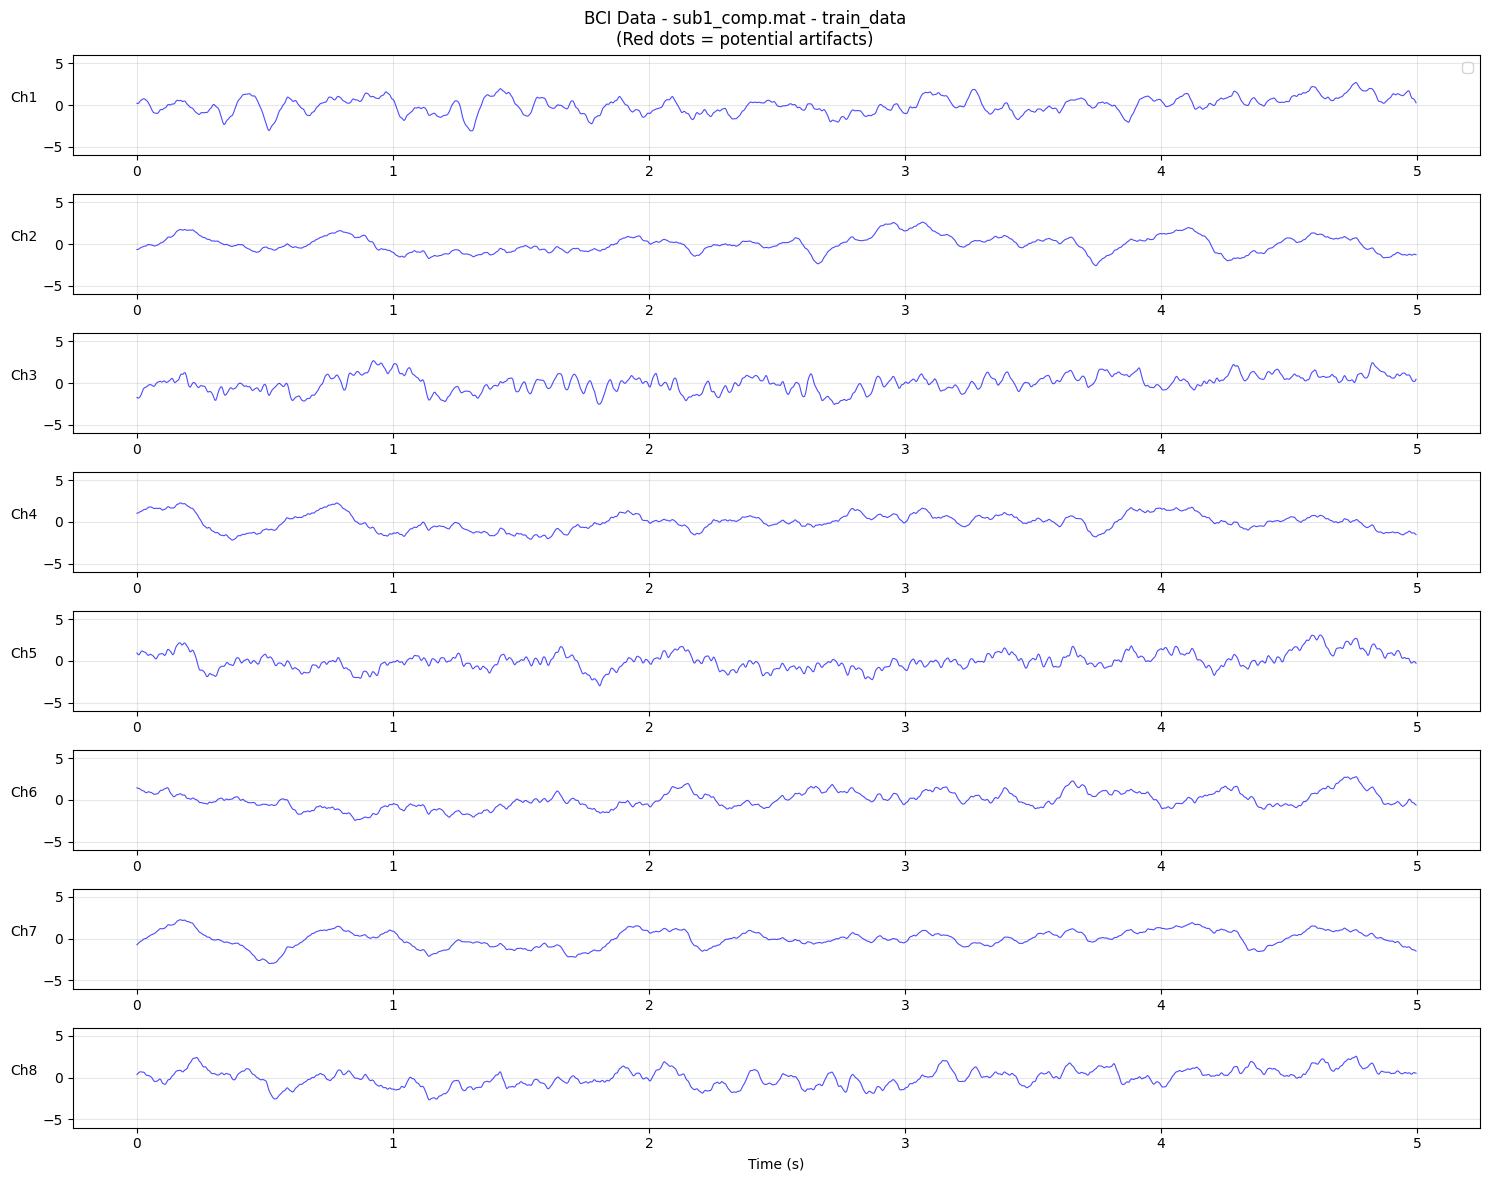


Statistical Artifact Detection - sub1_comp.mat - train_data:
--------------------------------------------------
Ch 1:  134 artifacts (  0.03%) | Max: 11908.00 | Std: 2156.94 | High-Amplitude
Ch 2:  675 artifacts (  0.17%) | Max: 35234.00 | Std: 3780.14 | High-Amplitude
Ch 3:   88 artifacts (  0.02%) | Max: 10369.00 | Std: 2135.21 | Clean
Ch 4: 1960 artifacts (  0.49%) | Max: 33151.00 | Std: 3542.16 | High-Amplitude
Ch 5:  586 artifacts (  0.15%) | Max: 29521.00 | Std: 2746.18 | High-Amplitude
Ch 6:  243 artifacts (  0.06%) | Max: 14807.00 | Std: 2584.18 | High-Amplitude
Ch 7: 1219 artifacts (  0.30%) | Max: 25901.00 | Std: 3116.59 | High-Amplitude
Ch 8:   65 artifacts (  0.02%) | Max: 9256.00 | Std: 1941.71 | Clean
Ch 9:  313 artifacts (  0.08%) | Max: 27692.00 | Std: 3495.11 | High-Amplitude
Ch10:  428 artifacts (  0.11%) | Max: 20734.00 | Std: 3075.07 | High-Amplitude

Analysing array: test_data (shape: (200000, 62))


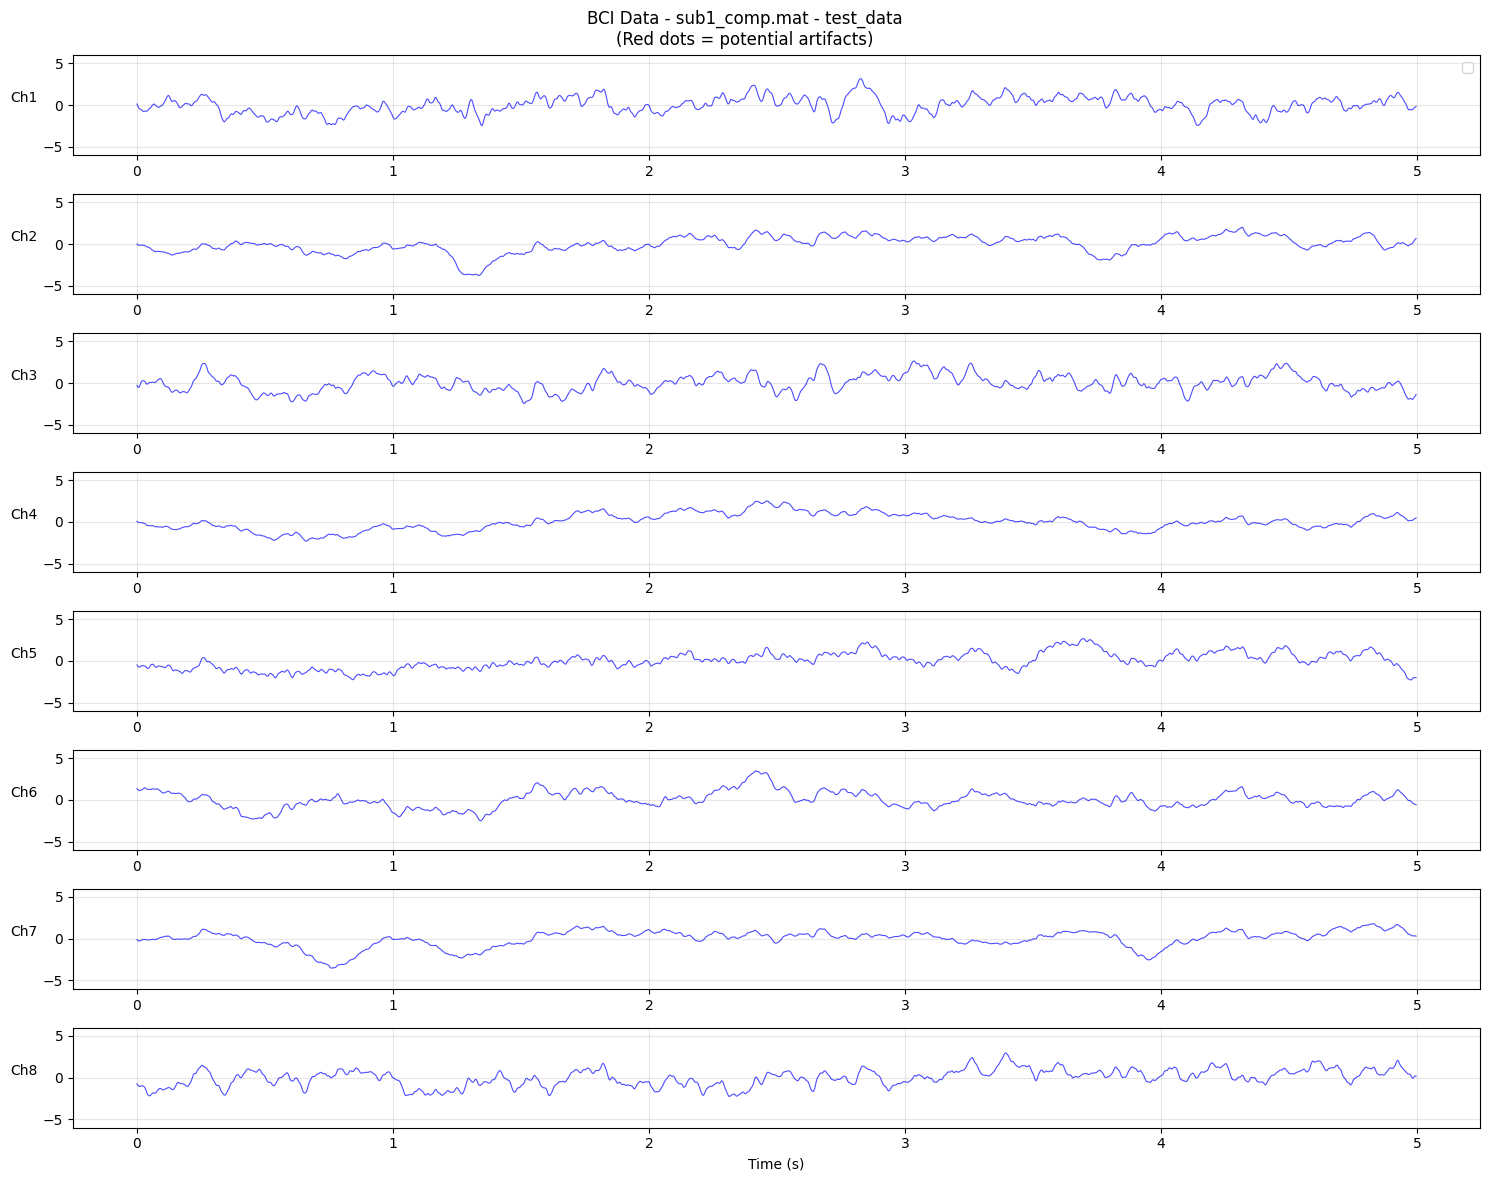


Statistical Artifact Detection - sub1_comp.mat - test_data:
--------------------------------------------------
Ch 1:   55 artifacts (  0.03%) | Max: 11433.00 | Std: 2215.41 | High-Amplitude
Ch 2:  238 artifacts (  0.12%) | Max: 27378.00 | Std: 4001.30 | High-Amplitude
Ch 3:   94 artifacts (  0.05%) | Max: 10919.00 | Std: 2193.94 | Clean
Ch 4:  429 artifacts (  0.21%) | Max: 29466.00 | Std: 3568.46 | High-Amplitude
Ch 5:  287 artifacts (  0.14%) | Max: 18006.00 | Std: 2866.29 | High-Amplitude
Ch 6:  287 artifacts (  0.14%) | Max: 16307.00 | Std: 2787.76 | High-Amplitude
Ch 7:  489 artifacts (  0.24%) | Max: 24241.00 | Std: 3128.43 | High-Amplitude
Ch 8:   23 artifacts (  0.01%) | Max: 8573.00 | Std: 2038.48 | Clean
Ch 9:  169 artifacts (  0.08%) | Max: 18618.00 | Std: 3796.19 | Clean
Ch10:  267 artifacts (  0.13%) | Max: 20316.00 | Std: 3143.21 | High-Amplitude

Analysing array: train_dg (shape: (400000, 5))


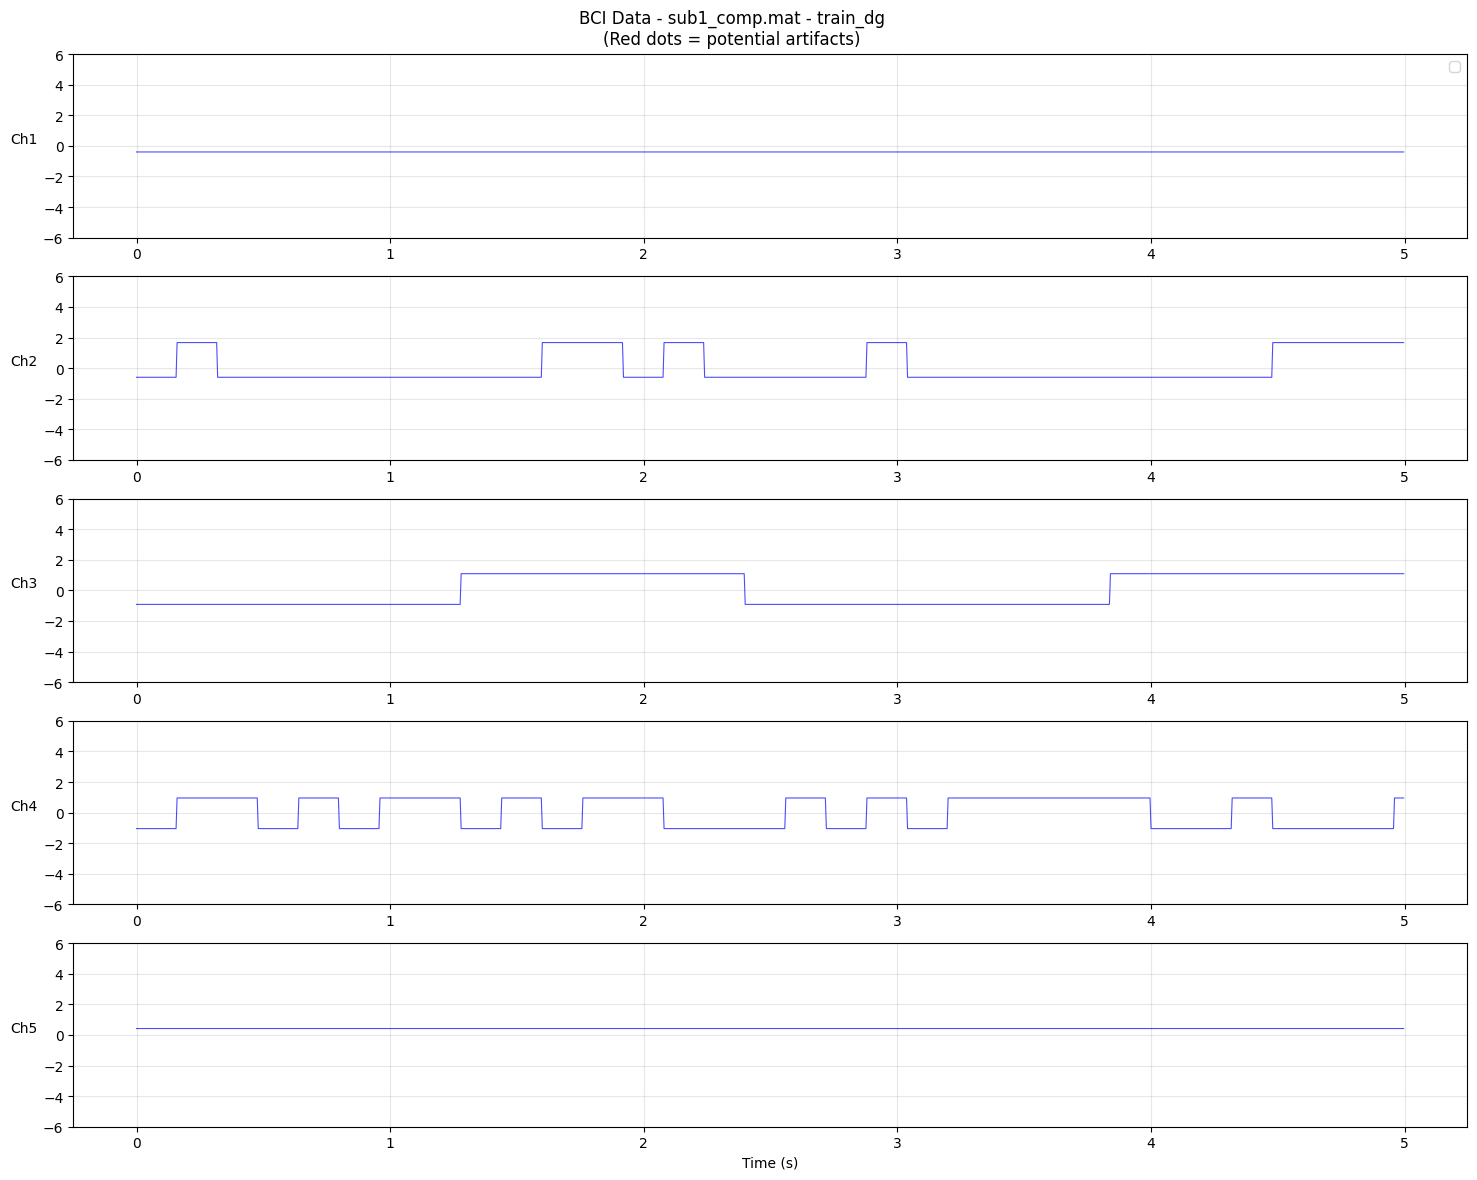


Statistical Artifact Detection - sub1_comp.mat - train_dg:
--------------------------------------------------
Ch 1: 10760 artifacts (  2.69%) | Max:    5.42 | Std:   0.85 | High-Amplitude
Ch 2: 5000 artifacts (  1.25%) | Max:    6.70 | Std:   1.04 | High-Amplitude
Ch 3: 4920 artifacts (  1.23%) | Max:    7.58 | Std:   1.08 | High-Amplitude
Ch 4: 7120 artifacts (  1.78%) | Max:    5.51 | Std:   0.94 | High-Amplitude
Ch 5: 4840 artifacts (  1.21%) | Max:    5.88 | Std:   1.05 | High-Amplitude

ARTEFAK ANALYSIS: sub2_comp.mat

Analysing array: train_data (shape: (400000, 48))


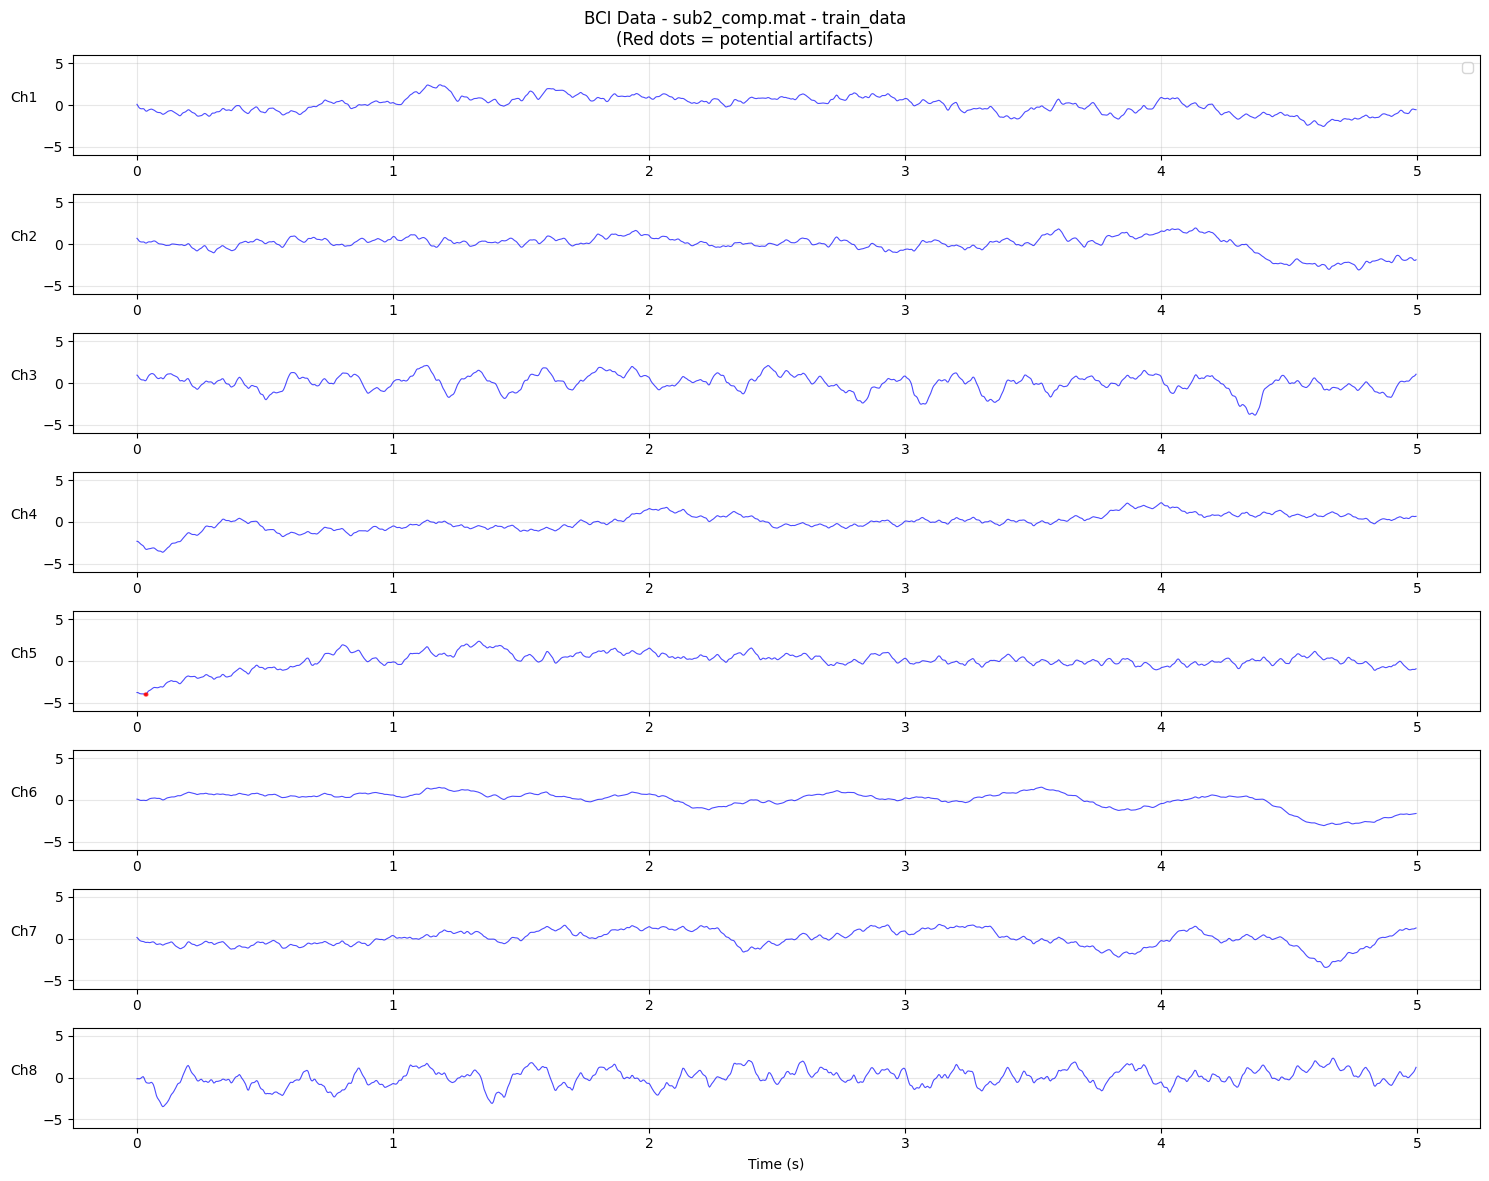


Statistical Artifact Detection - sub2_comp.mat - train_data:
--------------------------------------------------
Ch 1: 1600 artifacts (  0.40%) | Max: 22110.00 | Std: 3682.16 | High-Amplitude
Ch 2: 1095 artifacts (  0.27%) | Max: 18704.00 | Std: 2956.46 | High-Amplitude
Ch 3:   21 artifacts (  0.01%) | Max: 11096.00 | Std: 2482.70 | Clean
Ch 4:  450 artifacts (  0.11%) | Max: 14876.00 | Std: 2144.48 | High-Amplitude
Ch 5: 1024 artifacts (  0.26%) | Max: 25684.00 | Std: 2507.21 | High-Amplitude
Ch 6:  658 artifacts (  0.16%) | Max: 22977.00 | Std: 4703.85 | Clean
Ch 7:  158 artifacts (  0.04%) | Max: 11240.00 | Std: 1982.62 | High-Amplitude
Ch 8:   99 artifacts (  0.02%) | Max: 9595.00 | Std: 1991.53 | Clean
Ch 9:  270 artifacts (  0.07%) | Max: 8280.00 | Std: 1423.85 | High-Amplitude
Ch10:  781 artifacts (  0.20%) | Max: 25931.00 | Std: 4916.68 | High-Amplitude

Analysing array: test_data (shape: (200000, 48))


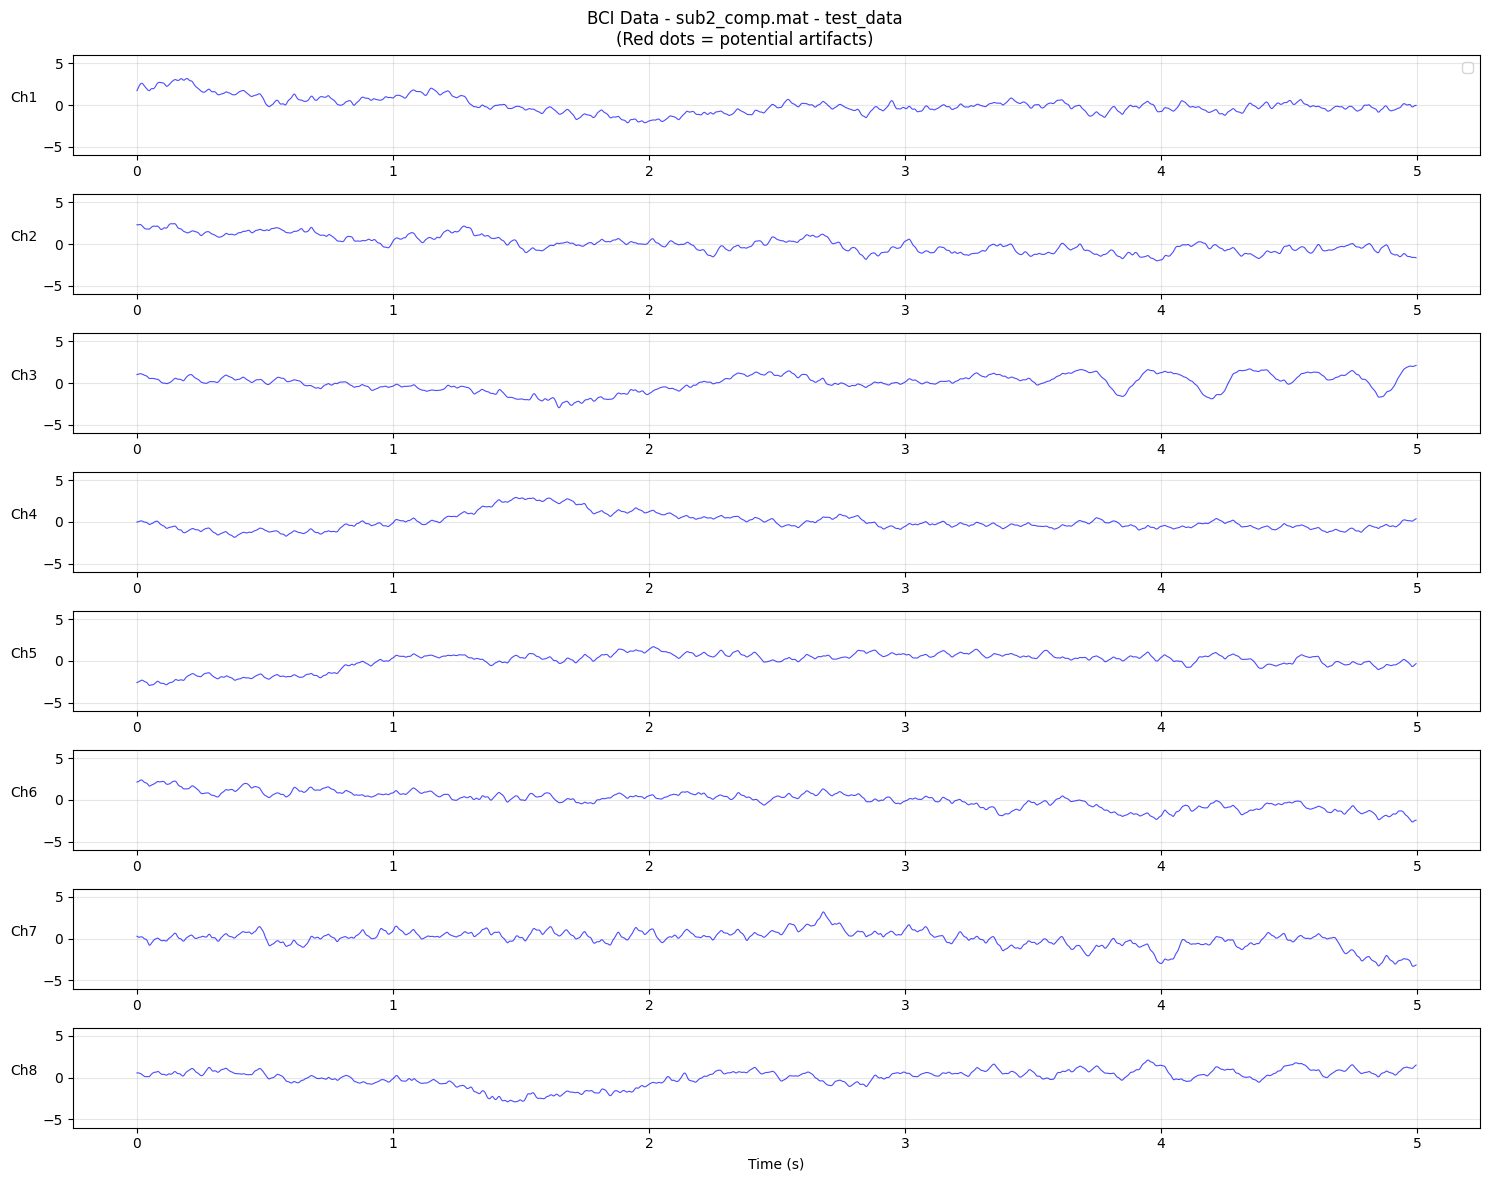


Statistical Artifact Detection - sub2_comp.mat - test_data:
--------------------------------------------------
Ch 1:  866 artifacts (  0.43%) | Max: 26281.00 | Std: 3602.39 | High-Amplitude
Ch 2:  324 artifacts (  0.16%) | Max: 17989.00 | Std: 2917.75 | High-Amplitude
Ch 3:   30 artifacts (  0.01%) | Max: 12571.00 | Std: 2463.67 | High-Amplitude
Ch 4:  282 artifacts (  0.14%) | Max: 12605.00 | Std: 2175.96 | High-Amplitude
Ch 5:  556 artifacts (  0.28%) | Max: 20997.00 | Std: 2703.87 | High-Amplitude
Ch 6:  542 artifacts (  0.27%) | Max: 24387.00 | Std: 4576.50 | High-Amplitude
Ch 7:  413 artifacts (  0.21%) | Max: 12142.00 | Std: 2056.99 | High-Amplitude
Ch 8:   87 artifacts (  0.04%) | Max: 8783.00 | Std: 1914.22 | Clean
Ch 9:  163 artifacts (  0.08%) | Max: 7447.00 | Std: 1417.07 | High-Amplitude
Ch10:  433 artifacts (  0.22%) | Max: 25132.00 | Std: 4937.77 | High-Amplitude

Analysing array: train_dg (shape: (400000, 5))


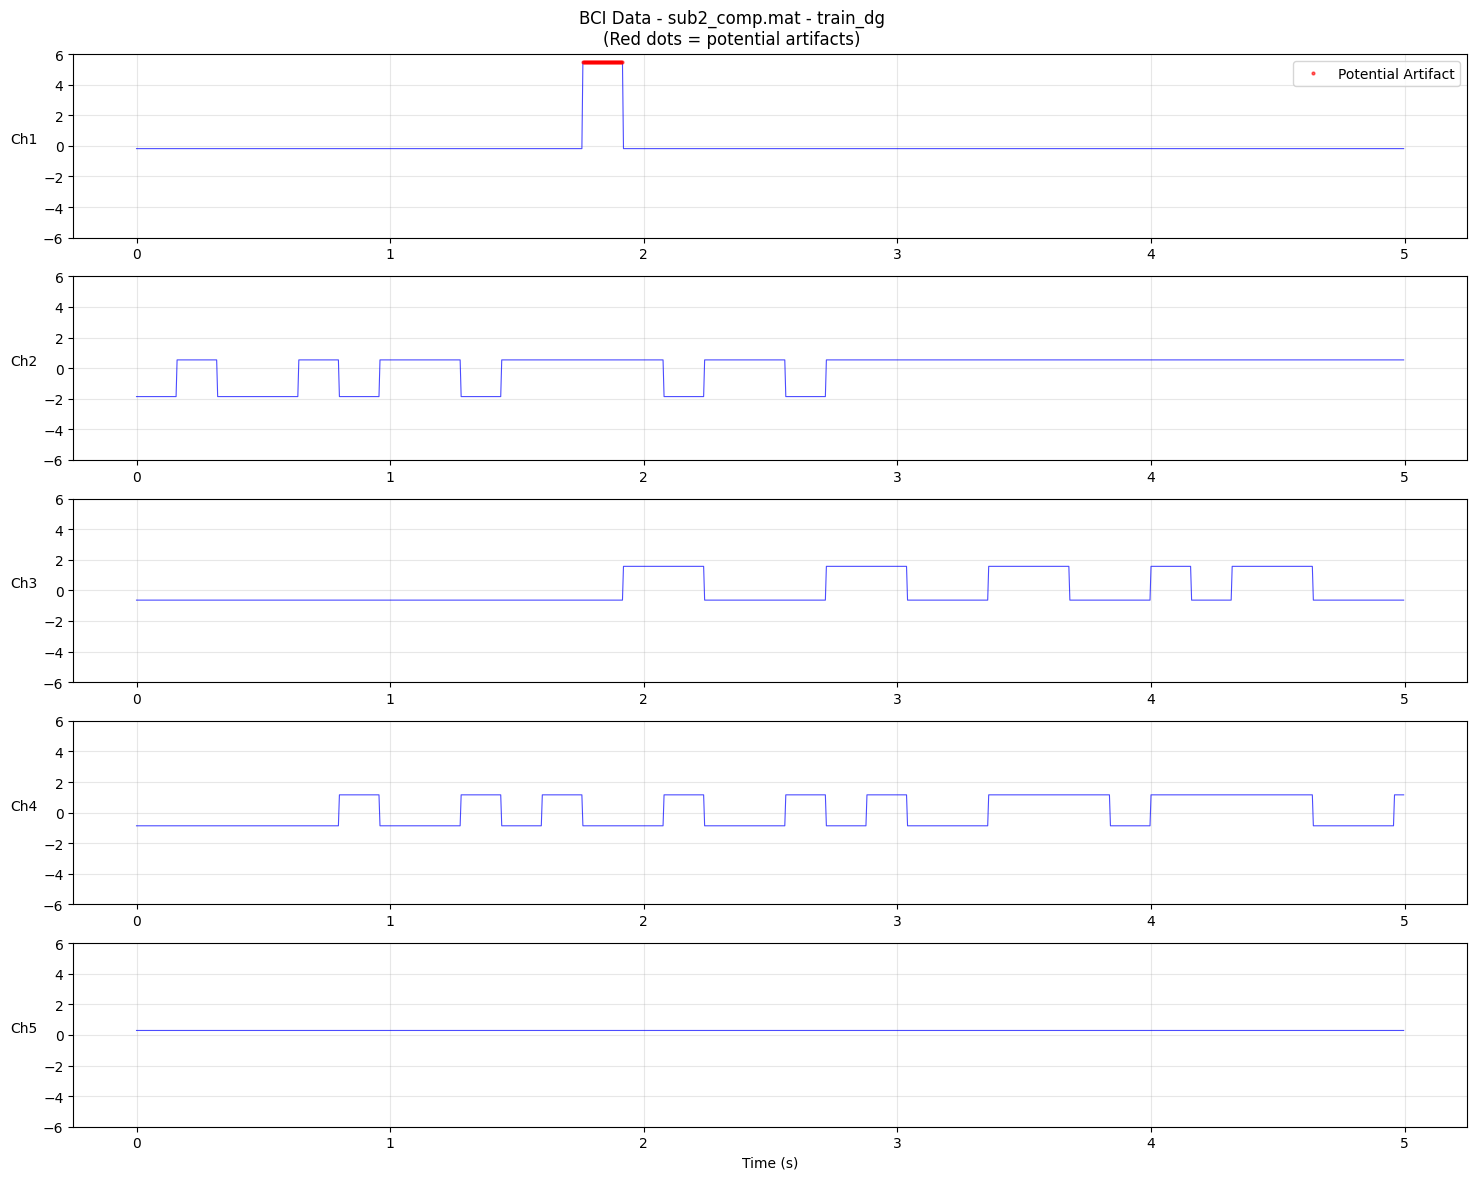


Statistical Artifact Detection - sub2_comp.mat - train_dg:
--------------------------------------------------
Ch 1: 8040 artifacts (  2.01%) | Max:    7.61 | Std:   1.01 | High-Amplitude
Ch 2: 10320 artifacts (  2.58%) | Max:    5.60 | Std:   0.99 | High-Amplitude
Ch 3: 9320 artifacts (  2.33%) | Max:    6.25 | Std:   1.14 | High-Amplitude
Ch 4: 8920 artifacts (  2.23%) | Max:    5.39 | Std:   0.96 | High-Amplitude
Ch 5: 9400 artifacts (  2.35%) | Max:    5.94 | Std:   0.92 | High-Amplitude

ARTEFAK ANALYSIS: sub3_comp.mat

Analysing array: train_data (shape: (400000, 64))


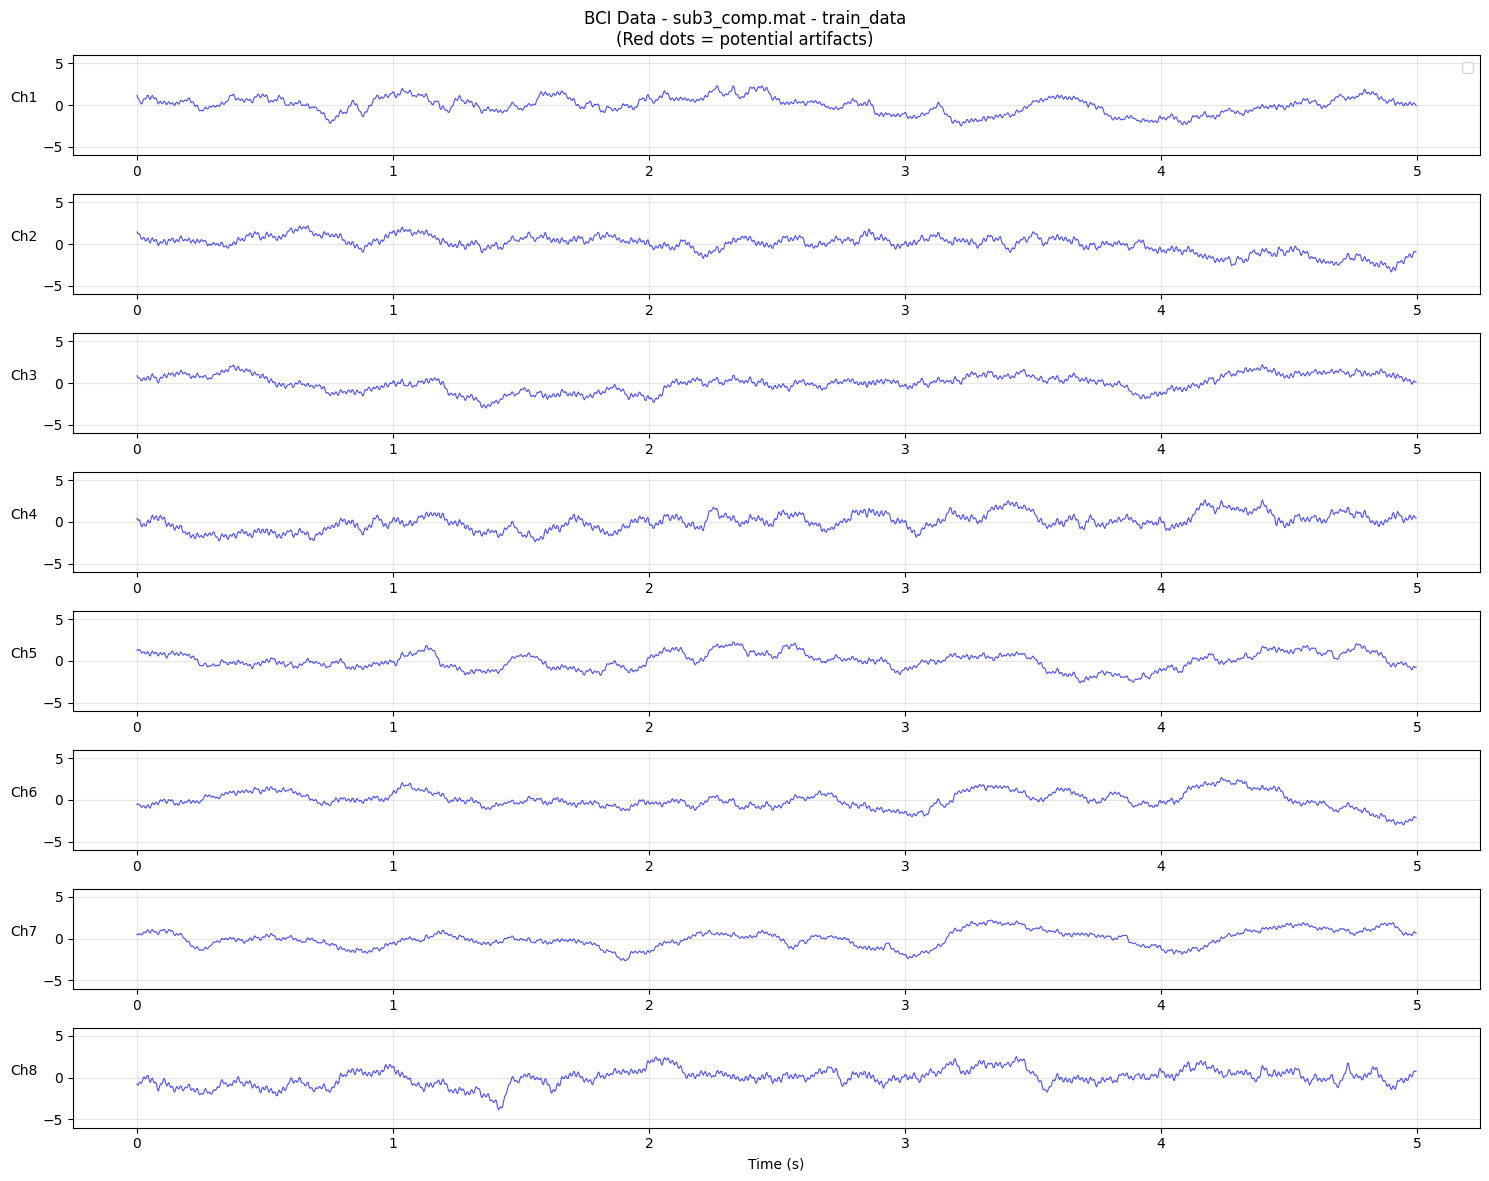


Statistical Artifact Detection - sub3_comp.mat - train_data:
--------------------------------------------------
Ch 1:  899 artifacts (  0.22%) | Max: 14462.00 | Std: 1679.16 | High-Amplitude
Ch 2:  141 artifacts (  0.04%) | Max: 6842.00 | Std: 1423.64 | Clean
Ch 3:  234 artifacts (  0.06%) | Max: 14359.00 | Std: 1584.26 | High-Amplitude
Ch 4:   20 artifacts (  0.01%) | Max: 6777.00 | Std: 1475.88 | Clean
Ch 5:  333 artifacts (  0.08%) | Max: 10796.00 | Std: 1739.63 | High-Amplitude
Ch 6:  156 artifacts (  0.04%) | Max: 7608.00 | Std: 1464.56 | High-Amplitude
Ch 7:   73 artifacts (  0.02%) | Max: 7755.00 | Std: 1588.55 | Clean
Ch 8:   35 artifacts (  0.01%) | Max: 6826.00 | Std: 1405.89 | Clean
Ch 9:  767 artifacts (  0.19%) | Max: 14631.00 | Std: 2134.69 | High-Amplitude
Ch10:  242 artifacts (  0.06%) | Max: 9533.00 | Std: 1679.02 | High-Amplitude

Analysing array: test_data (shape: (200000, 64))


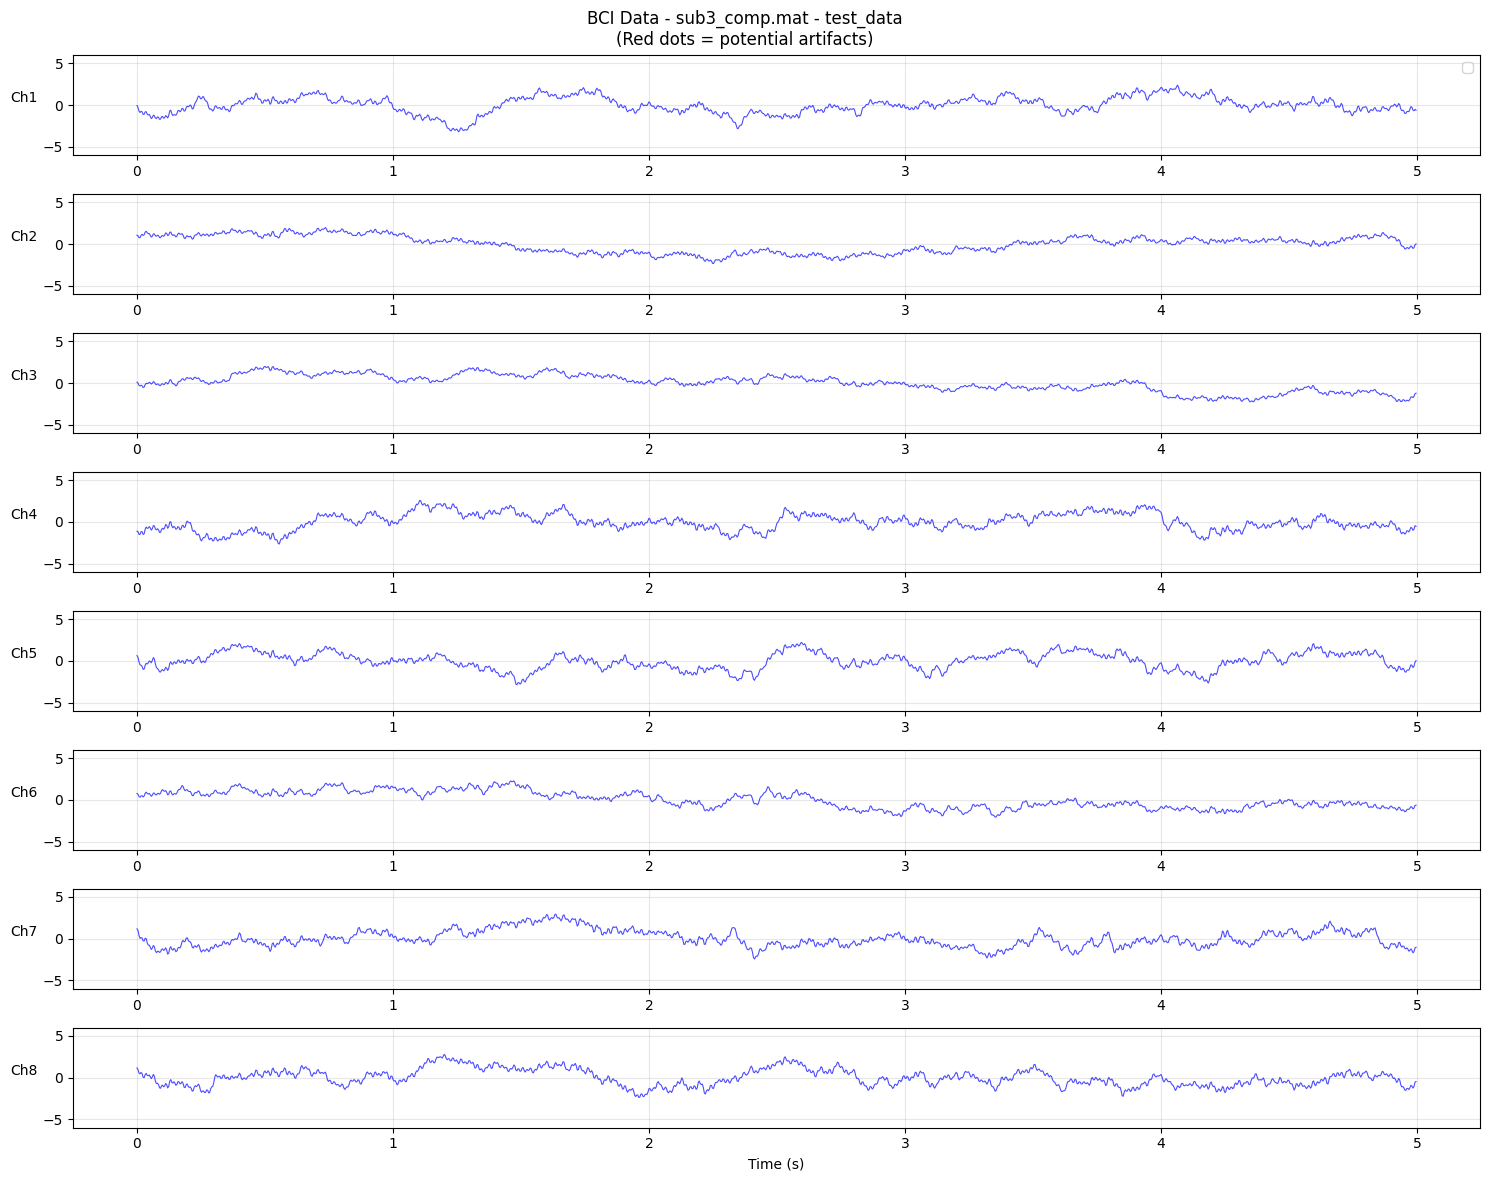


Statistical Artifact Detection - sub3_comp.mat - test_data:
--------------------------------------------------
Ch 1:  653 artifacts (  0.33%) | Max: 16825.00 | Std: 1755.26 | High-Amplitude
Ch 2:   96 artifacts (  0.05%) | Max: 7219.00 | Std: 1397.89 | High-Amplitude
Ch 3:  221 artifacts (  0.11%) | Max: 8883.00 | Std: 1653.74 | High-Amplitude
Ch 4:   27 artifacts (  0.01%) | Max: 6545.00 | Std: 1446.25 | Clean
Ch 5:  225 artifacts (  0.11%) | Max: 11803.00 | Std: 1742.31 | High-Amplitude
Ch 6:    5 artifacts (  0.00%) | Max: 6202.00 | Std: 1465.38 | Clean
Ch 7:  101 artifacts (  0.05%) | Max: 9685.00 | Std: 1600.57 | High-Amplitude
Ch 8:   37 artifacts (  0.02%) | Max: 6814.00 | Std: 1400.47 | Clean
Ch 9:  672 artifacts (  0.34%) | Max: 16451.00 | Std: 2244.73 | High-Amplitude
Ch10:   65 artifacts (  0.03%) | Max: 7676.00 | Std: 1657.46 | Clean

Analysing array: train_dg (shape: (400000, 5))


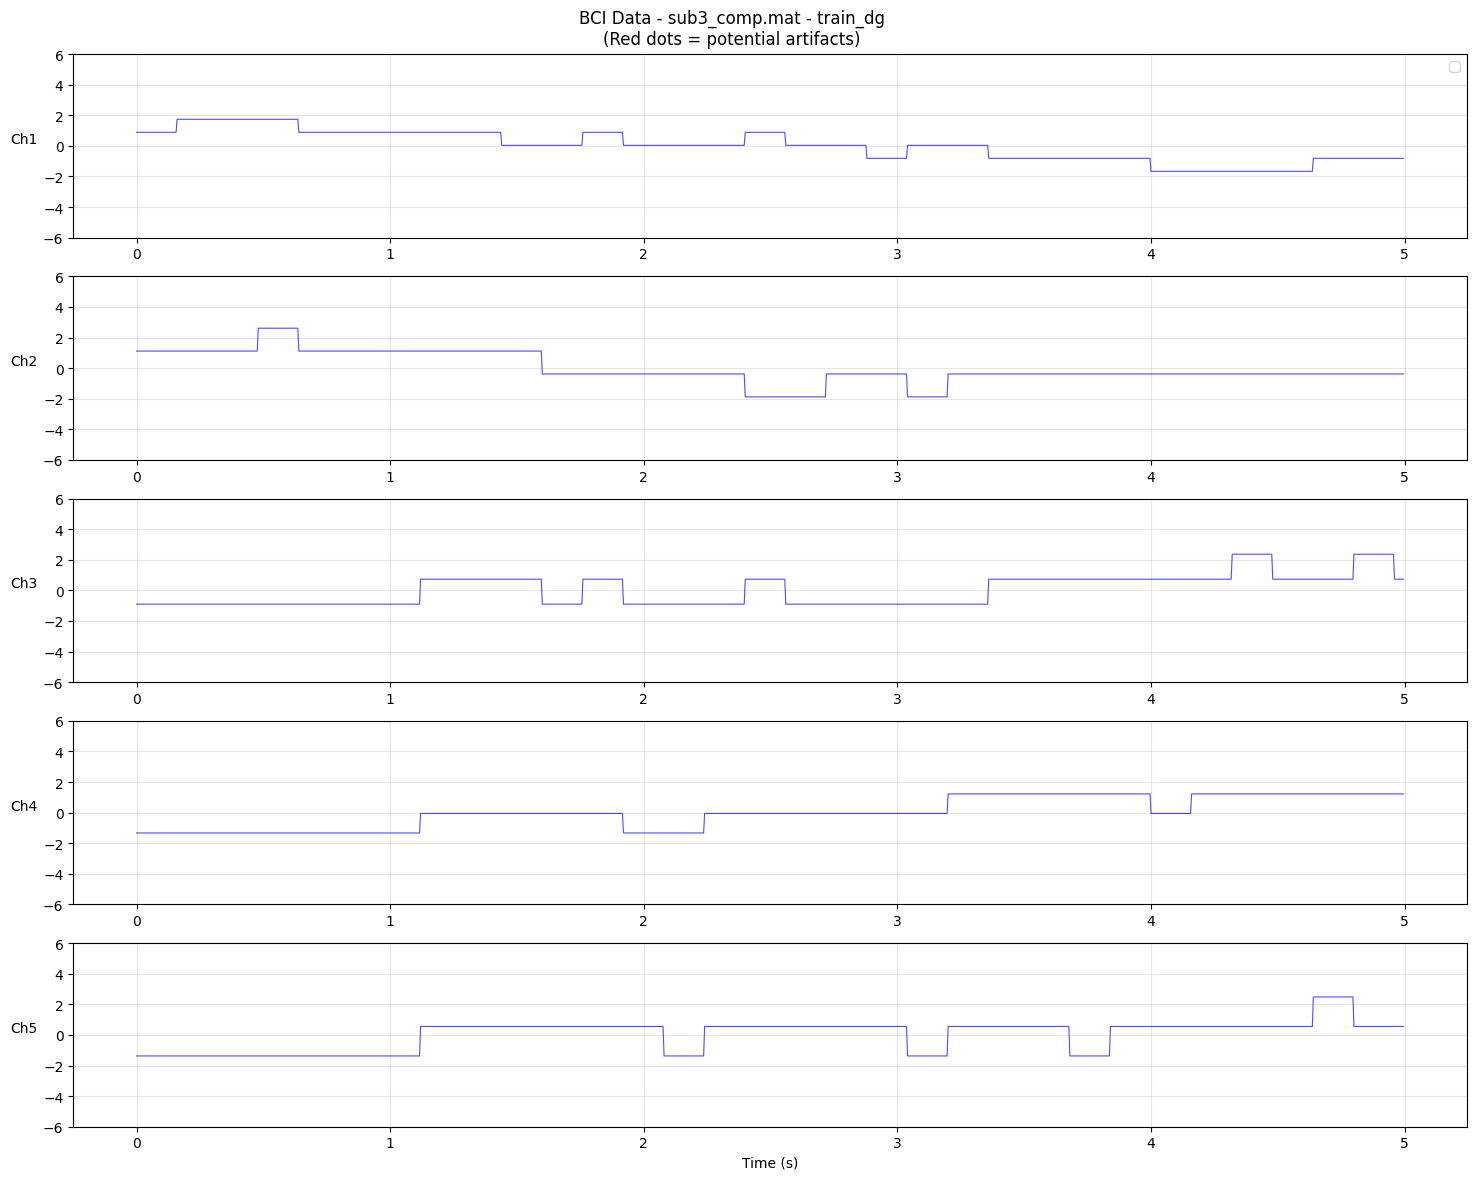


Statistical Artifact Detection - sub3_comp.mat - train_dg:
--------------------------------------------------
Ch 1: 1360 artifacts (  0.34%) | Max:    4.82 | Std:   1.06 | Clean
Ch 2:  440 artifacts (  0.11%) | Max:    4.42 | Std:   1.02 | Clean
Ch 3:    0 artifacts (  0.00%) | Max:    2.81 | Std:   1.04 | Clean
Ch 4:    0 artifacts (  0.00%) | Max:    2.80 | Std:   1.09 | Clean
Ch 5: 1400 artifacts (  0.35%) | Max:    4.80 | Std:   1.00 | Clean


In [9]:
# Analisis setiap file BCI yang berhasil di-load
if loaded_bci_data:
    for file_name, data in loaded_bci_data.items():
        analyze_bci_artifacts(data, file_name)
else:
    print("\nTidak ada data BCI yang bisa dianalisis!")


Power Spectrum Analysis: sub1_comp.mat - train_data


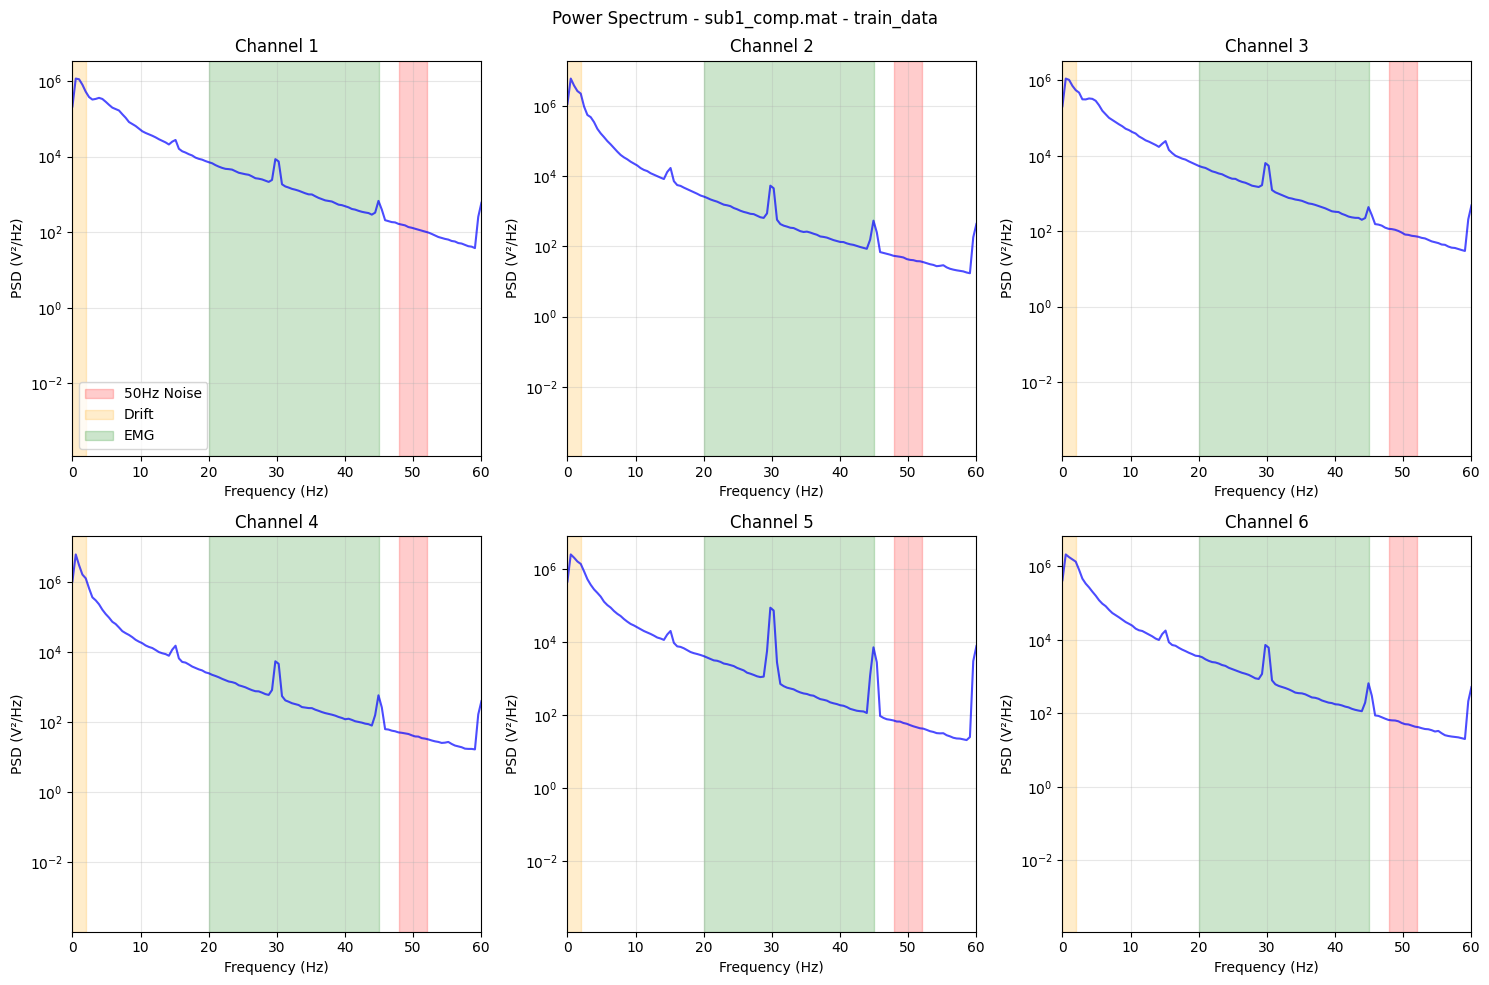


Power Spectrum Analysis: sub1_comp.mat - test_data


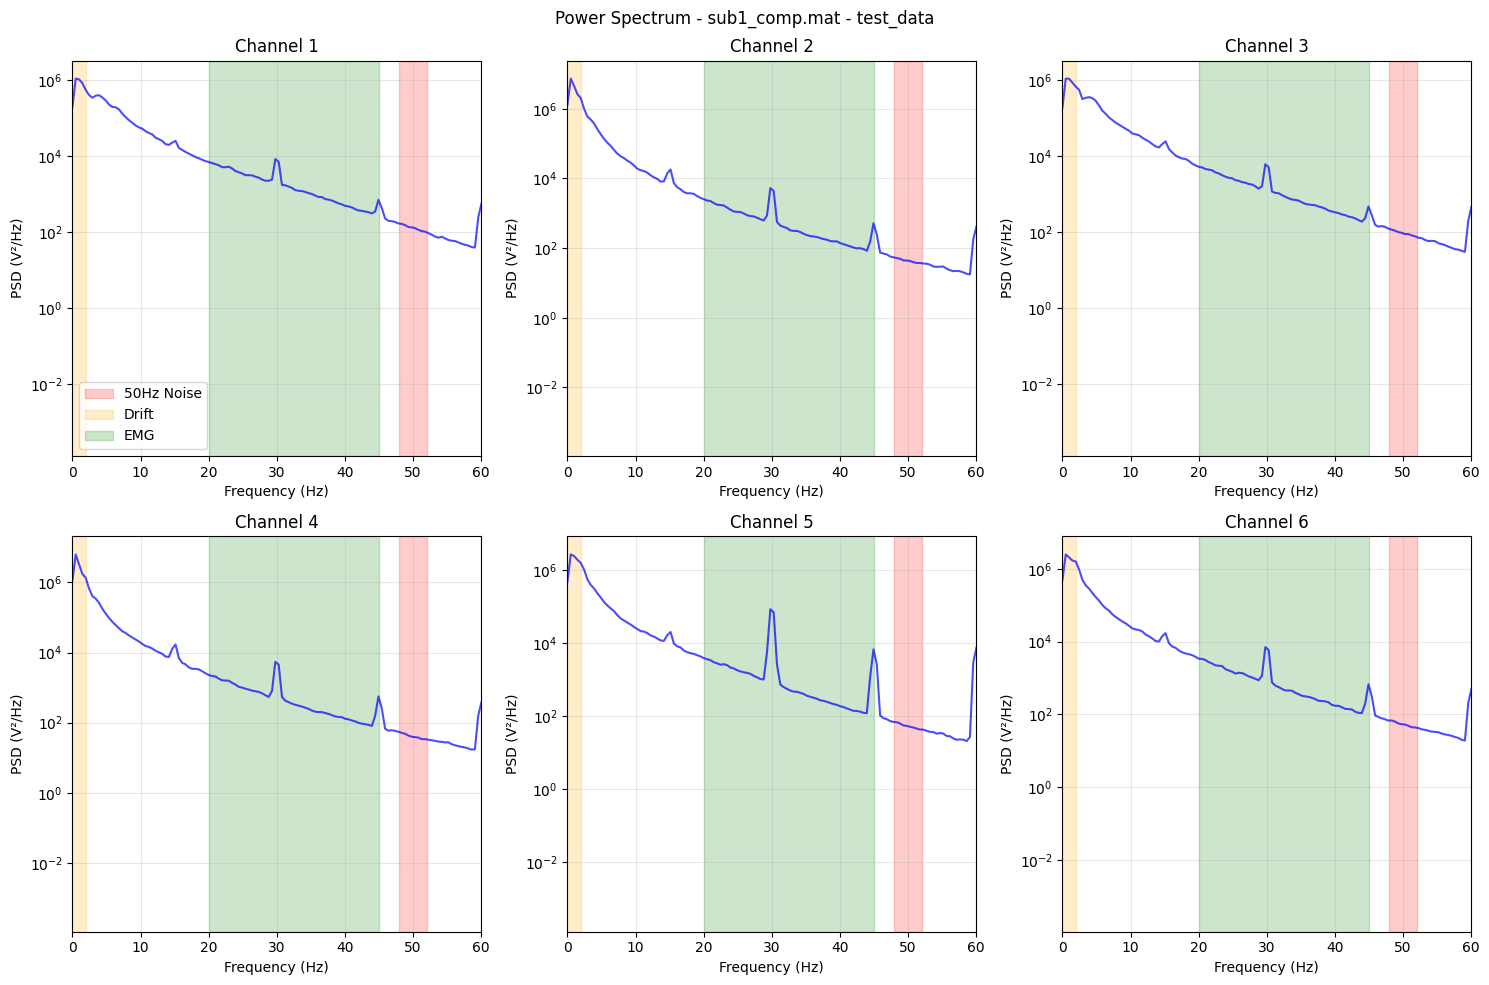


Power Spectrum Analysis: sub1_comp.mat - train_dg


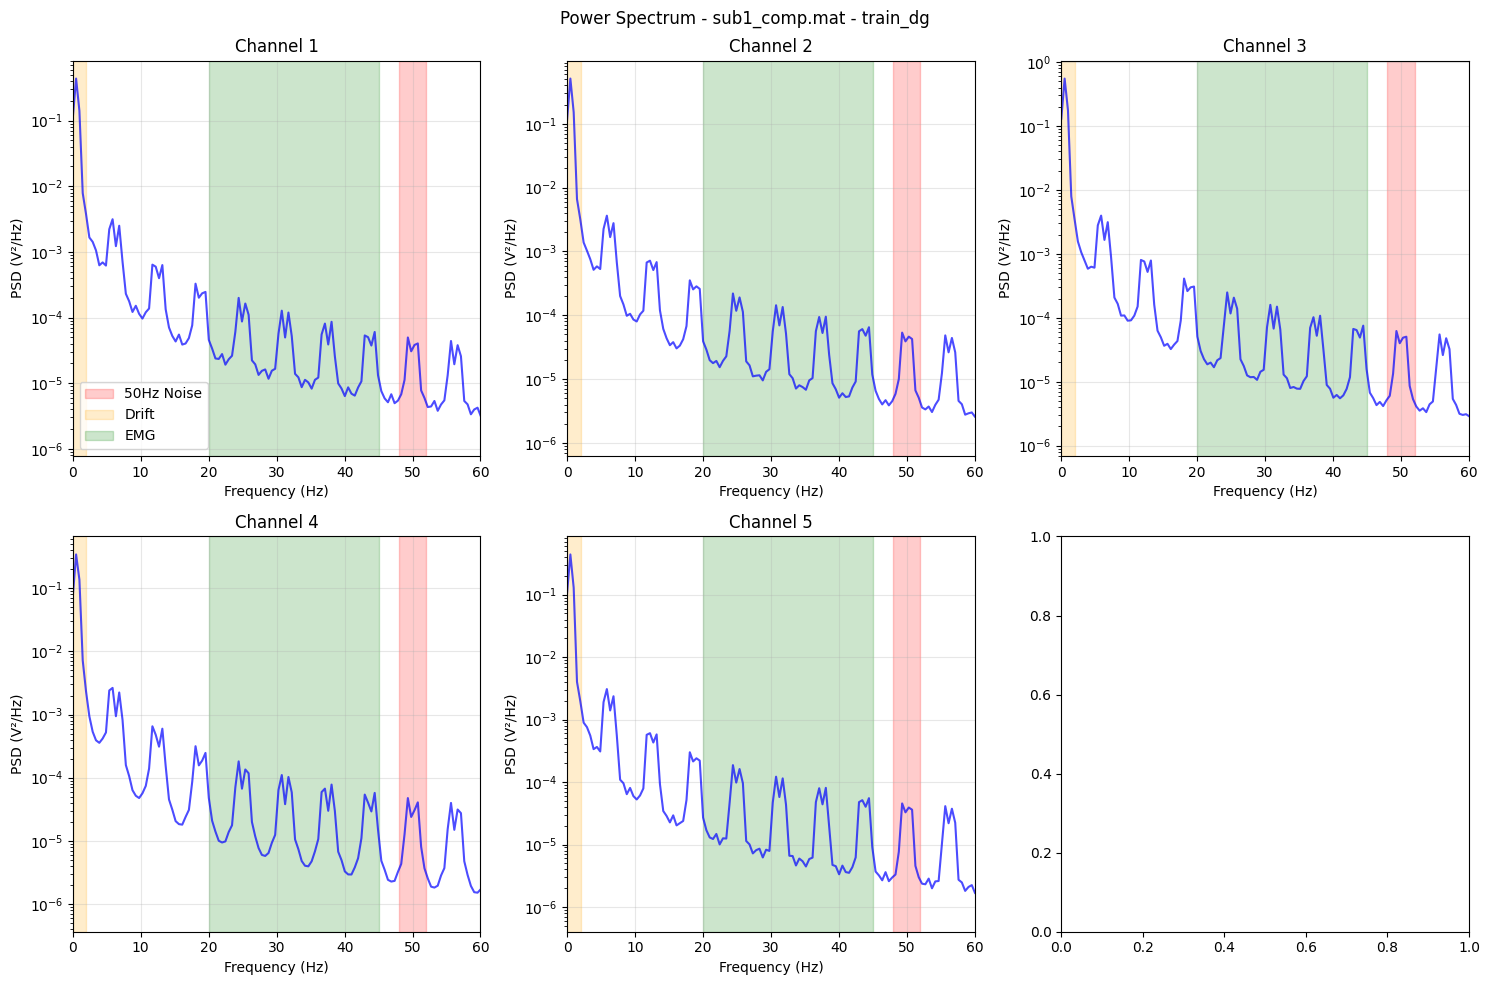


Power Spectrum Analysis: sub2_comp.mat - train_data


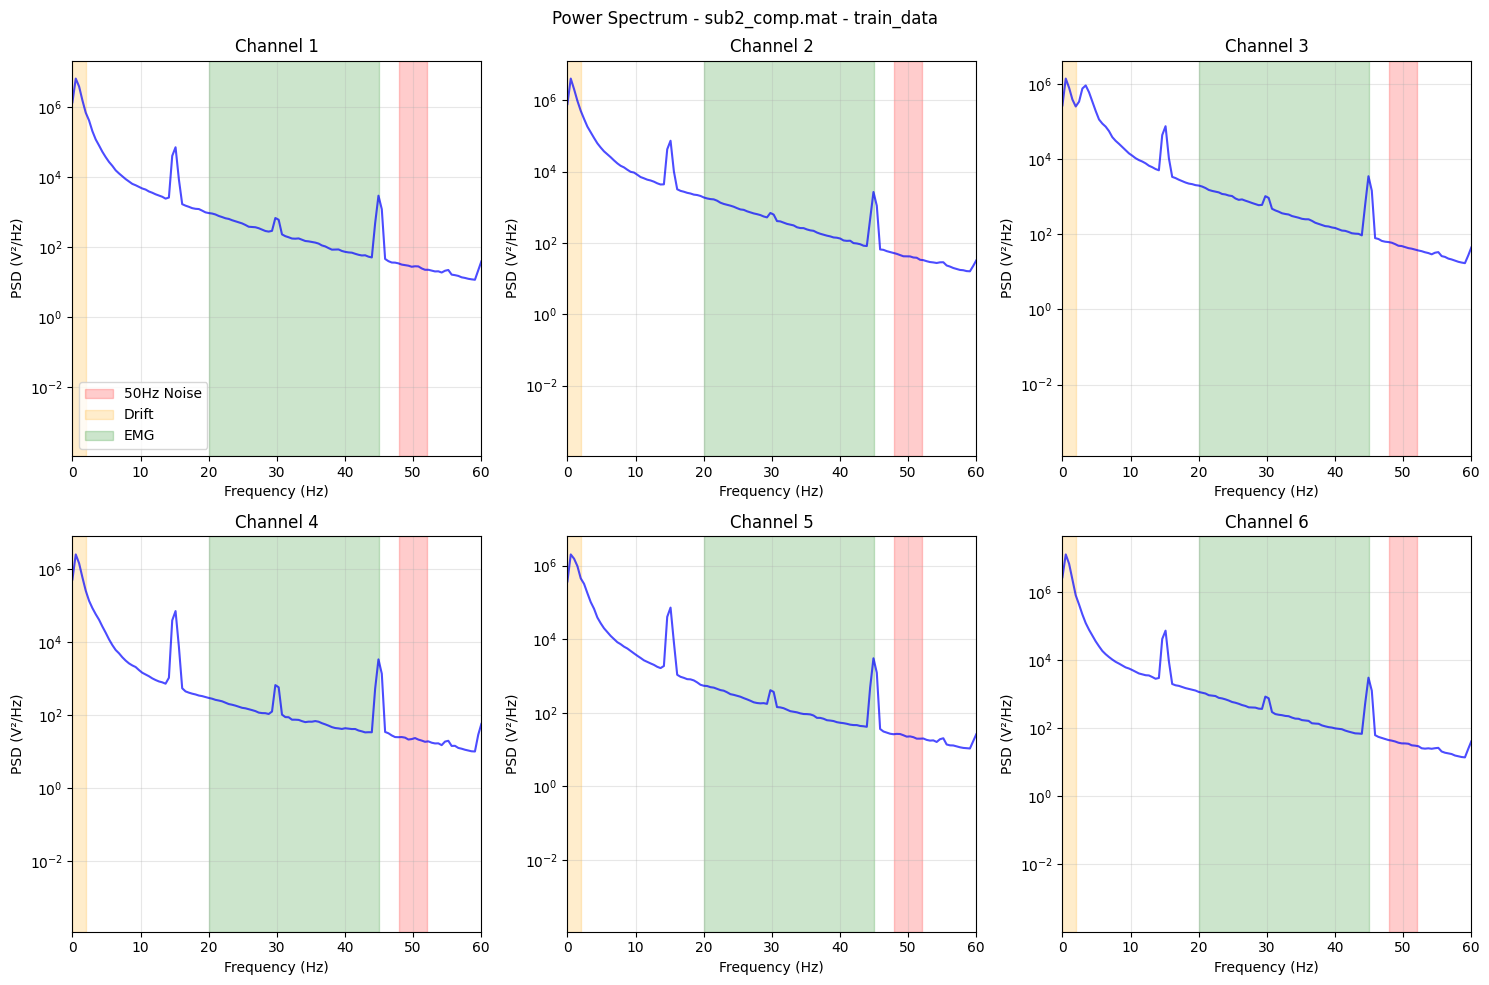


Power Spectrum Analysis: sub2_comp.mat - test_data


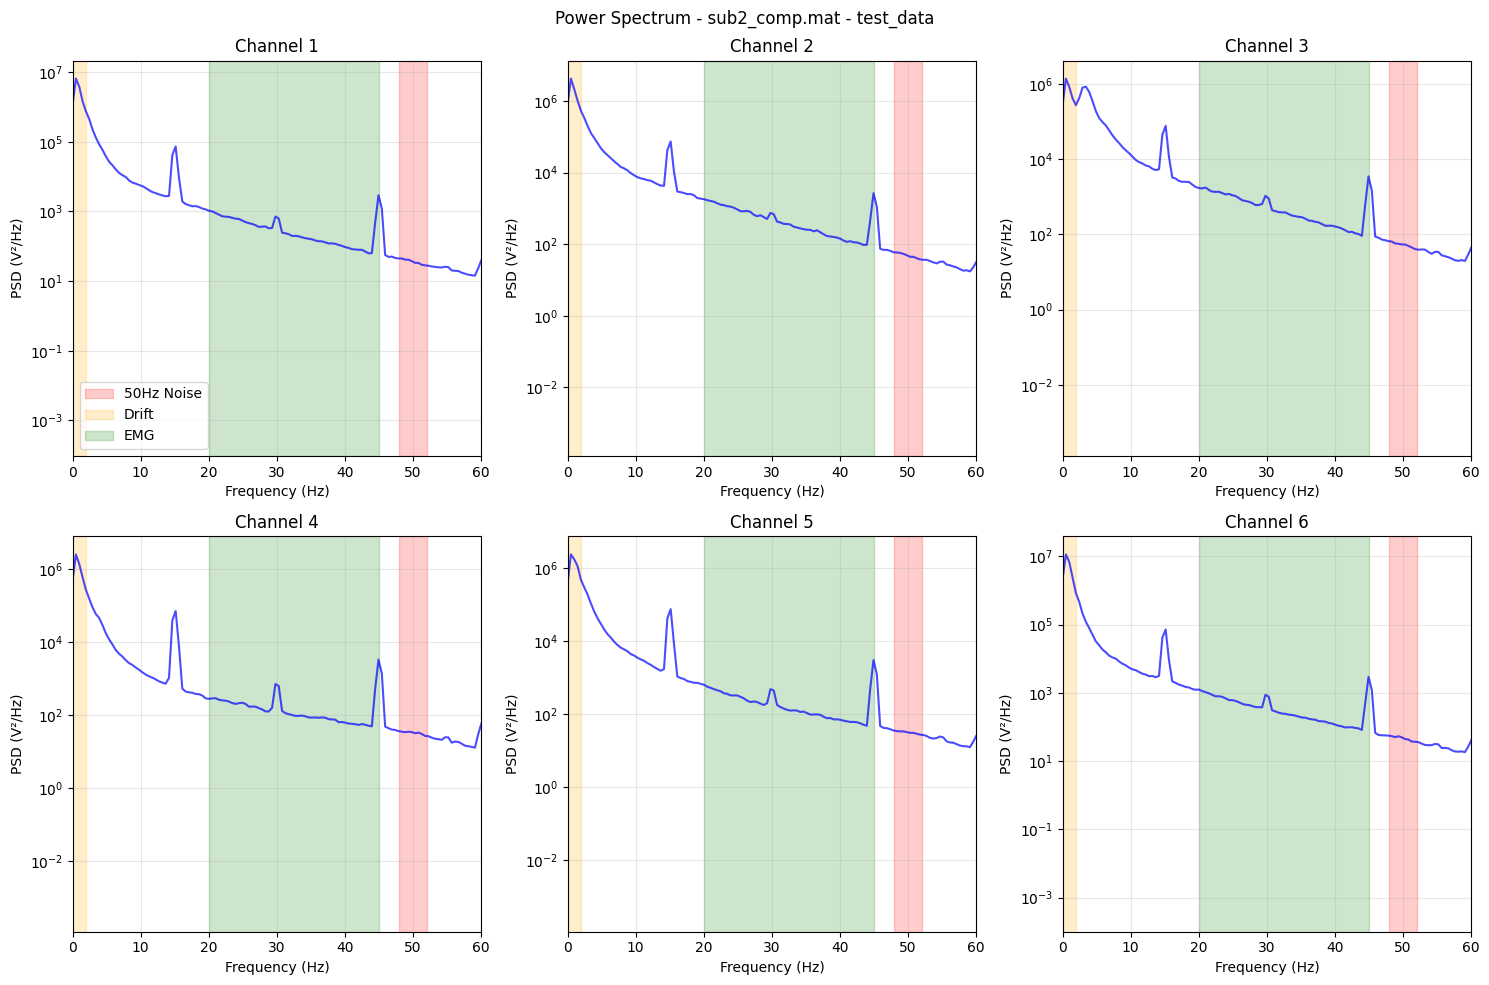


Power Spectrum Analysis: sub2_comp.mat - train_dg


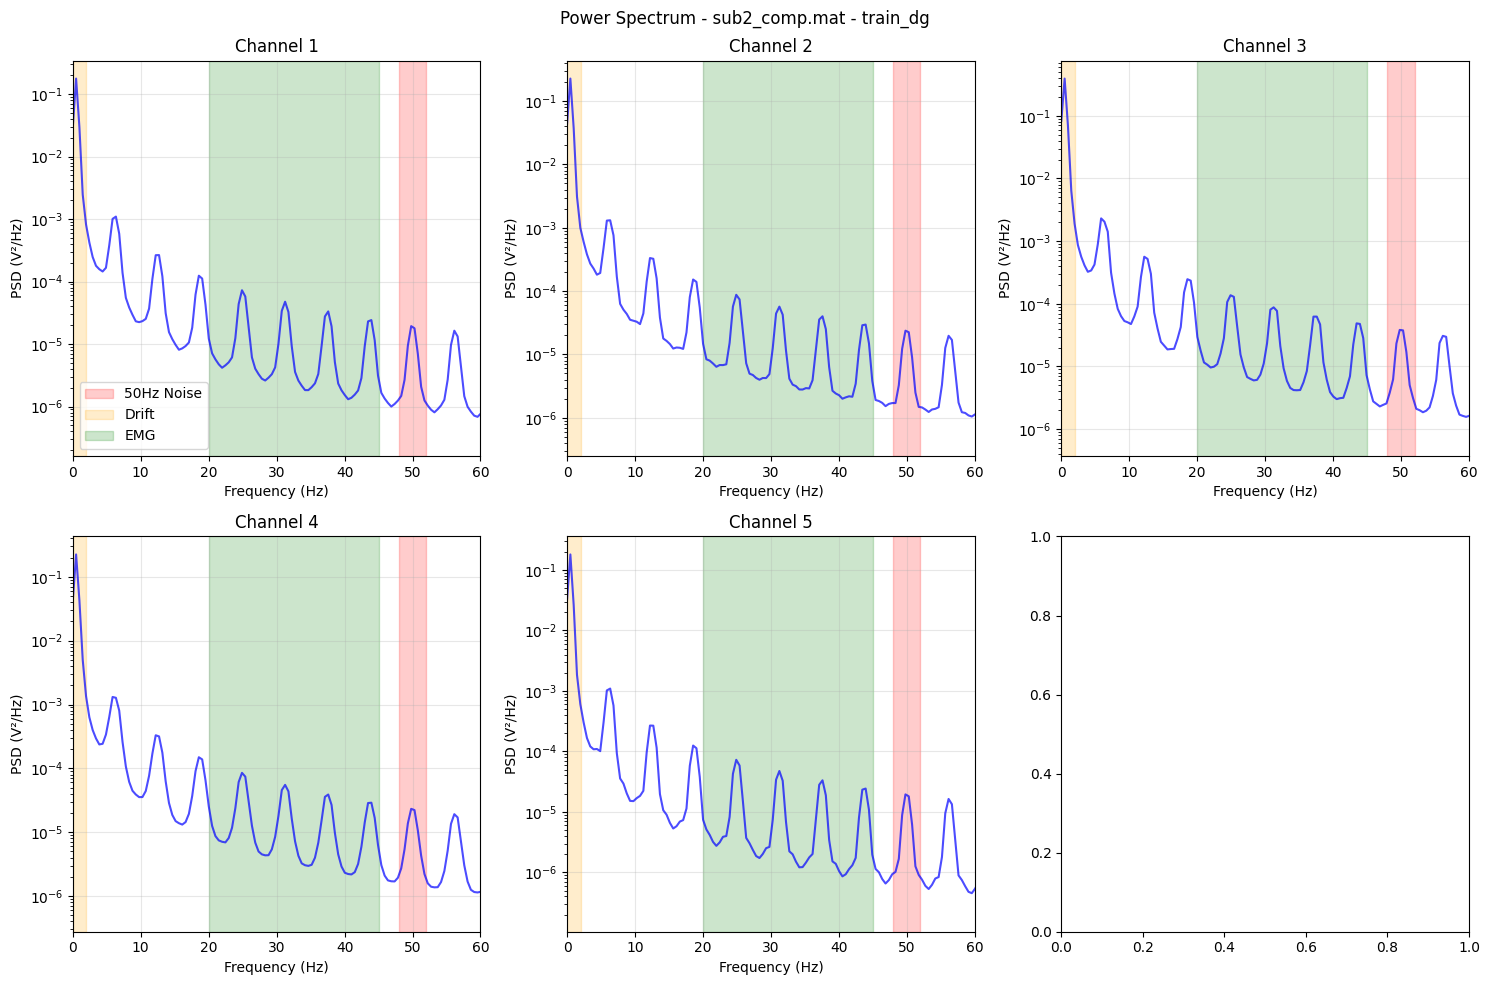


Power Spectrum Analysis: sub3_comp.mat - train_data


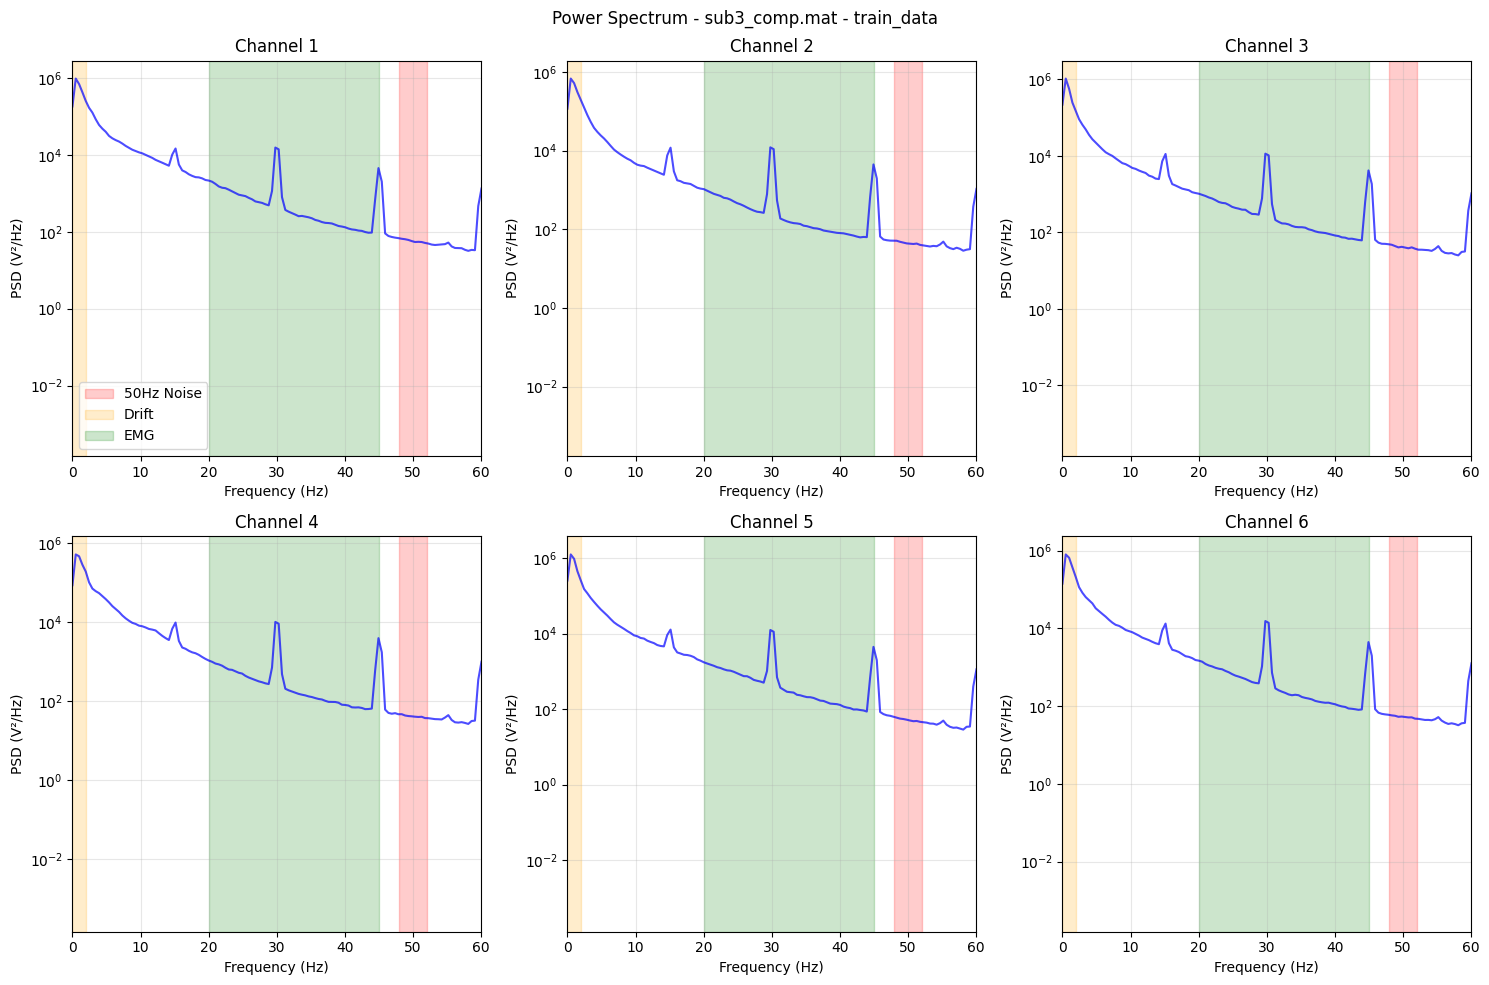


Power Spectrum Analysis: sub3_comp.mat - test_data


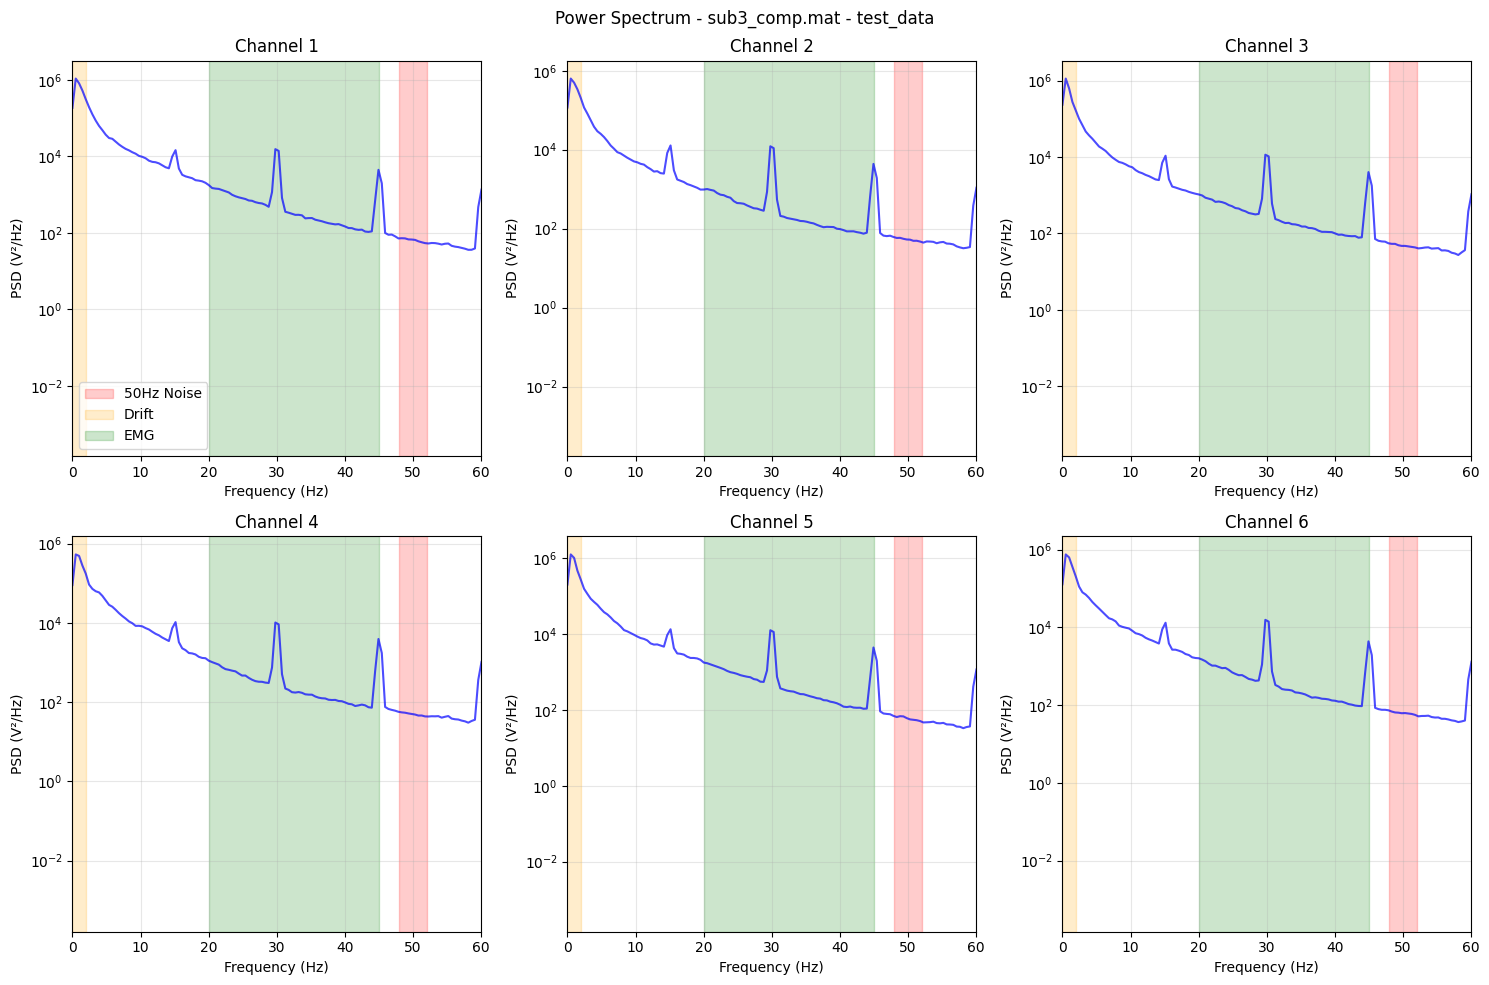


Power Spectrum Analysis: sub3_comp.mat - train_dg


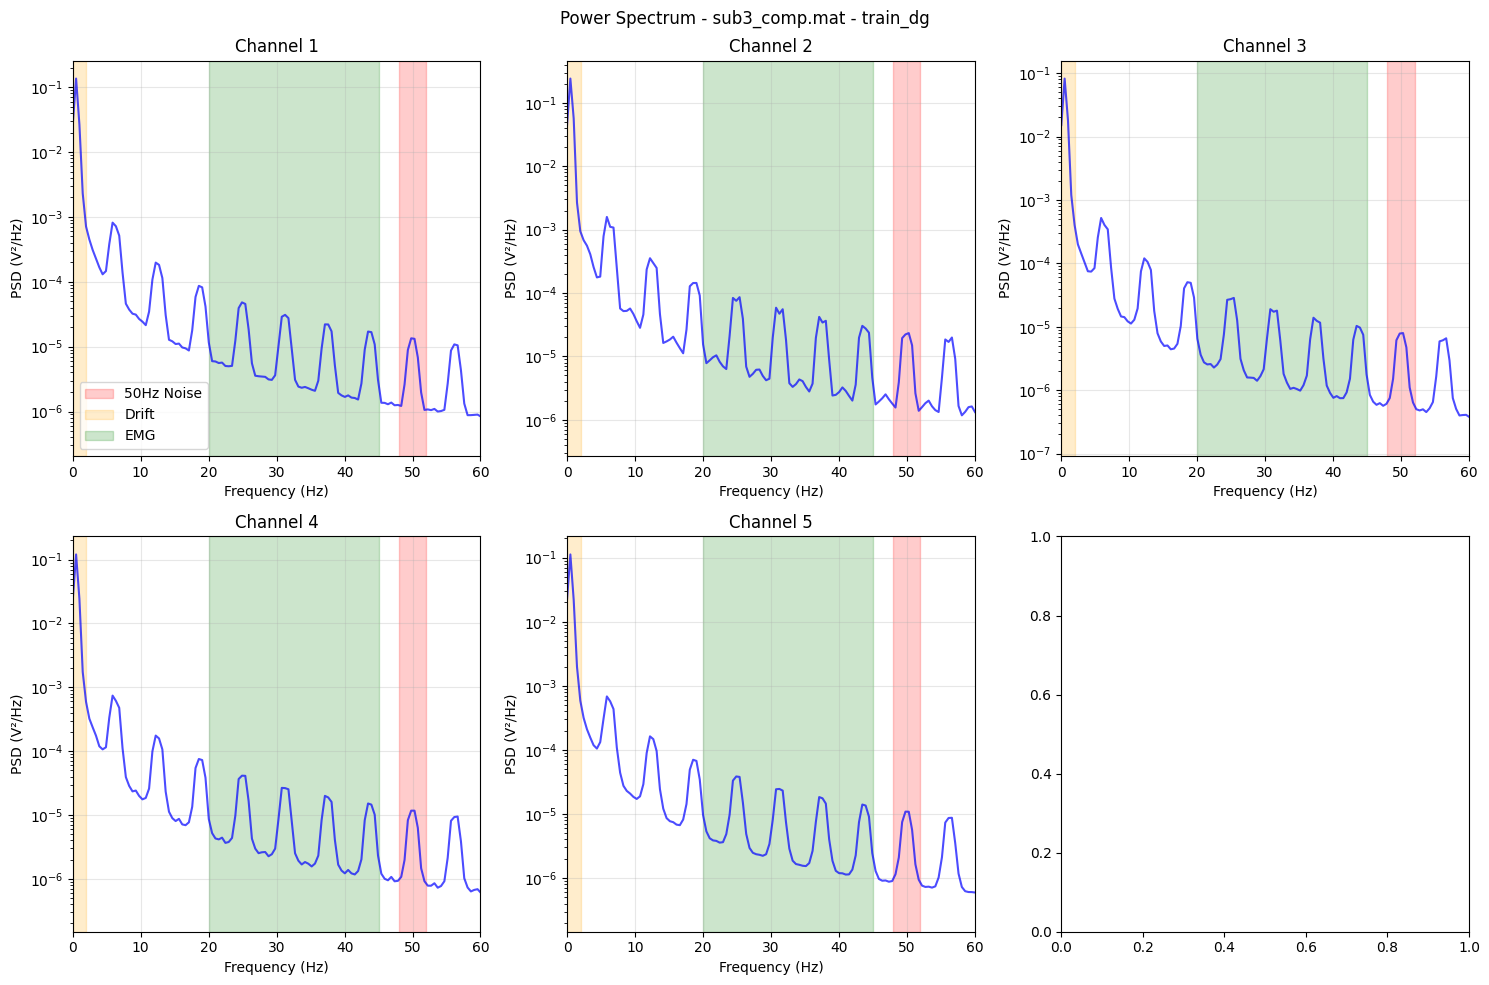

In [10]:
def plot_bci_power_spectrum(data_dict, file_name):
    """
    Analisis power spectrum untuk deteksi artefak frekuensi
    """
    for key, value in data_dict.items():
        if not key.startswith('__') and isinstance(value, np.ndarray) and value.ndim >= 2:
            print(f"\nPower Spectrum Analysis: {file_name} - {key}")
            
            if value.ndim == 2:
                eeg_data = value if value.shape[0] < value.shape[1] else value.T
            else:  # 3D
                eeg_data = value[0]  # Trial pertama
            
            n_channels = min(6, eeg_data.shape[0])
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.flatten()
            
            for i in range(n_channels):
                # Compute PSD
                f, Pxx = signal.welch(eeg_data[i, :], fs=250, nperseg=512)
                
                # Plot
                axes[i].semilogy(f, Pxx, 'b-', alpha=0.7)
                axes[i].set_xlim(0, 60)
                axes[i].set_xlabel('Frequency (Hz)')
                axes[i].set_ylabel('PSD (V²/Hz)')
                axes[i].set_title(f'Channel {i+1}')
                axes[i].grid(True, alpha=0.3)
                
                # Highlight artefak regions
                axes[i].axvspan(48, 52, alpha=0.2, color='red', label='50Hz Noise')
                axes[i].axvspan(0, 2, alpha=0.2, color='orange', label='Drift')
                axes[i].axvspan(20, 45, alpha=0.2, color='green', label='EMG')
                
                if i == 0:
                    axes[i].legend()
            
            plt.suptitle(f'Power Spectrum - {file_name} - {key}')
            plt.tight_layout()
            plt.show()

# Plot power spectrum untuk setiap file
if loaded_bci_data:
    for file_name, data in loaded_bci_data.items():
        plot_bci_power_spectrum(data, file_name)

In [11]:
def generate_artifact_summary(loaded_bci_data):
    """
    Generate summary report untuk semua data BCI
    """
    print("\n" + "="*70)
    print("BCI COMPETITION ARTIFACT SUMMARY REPORT")
    print("="*70)
    
    for file_name, data in loaded_bci_data.items():
        print(f"\n📁 FILE: {file_name}")
        print("-" * 50)
        
        total_channels = 0
        noisy_channels = 0
        clean_channels = 0
        
        for key, value in data.items():
            if not key.startswith('__') and isinstance(value, np.ndarray) and value.ndim >= 2:
                if value.ndim == 2:
                    eeg_data = value if value.shape[0] < value.shape[1] else value.T
                    n_channels = eeg_data.shape[0]
                else:
                    eeg_data = value[0]
                    n_channels = eeg_data.shape[0]
                
                total_channels += n_channels
                
                # Quick assessment
                for ch in range(min(5, n_channels)):  # Cek 5 channel pertama
                    channel_data = eeg_data[ch, :]
                    std_val = np.std(channel_data)
                    max_val = np.max(np.abs(channel_data))
                    
                    if max_val > 5 * std_val or std_val > 100:
                        noisy_channels += 1
                        status = "🚩 NOISY"
                    else:
                        clean_channels += 1
                        status = "✅ CLEAN"
                    
                    print(f"  {key} - Ch{ch+1}: {status} (std: {std_val:.1f}, max: {max_val:.1f})")
        
        if total_channels > 0:
            noise_percentage = (noisy_channels / total_channels) * 100
            print(f"\n  📊 SUMMARY: {noisy_channels}/{total_channels} channels noisy ({noise_percentage:.1f}%)")

# Generate summary
if loaded_bci_data:
    generate_artifact_summary(loaded_bci_data)
else:
    print("Tidak ada data untuk dianalisis!")


BCI COMPETITION ARTIFACT SUMMARY REPORT

📁 FILE: sub1_comp.mat
--------------------------------------------------
  train_data - Ch1: 🚩 NOISY (std: 2156.9, max: 11908.0)
  train_data - Ch2: 🚩 NOISY (std: 3780.1, max: 35234.0)
  train_data - Ch3: 🚩 NOISY (std: 2135.2, max: 10369.0)
  train_data - Ch4: 🚩 NOISY (std: 3542.2, max: 33151.0)
  train_data - Ch5: 🚩 NOISY (std: 2746.2, max: 29521.0)
  test_data - Ch1: 🚩 NOISY (std: 2215.4, max: 11433.0)
  test_data - Ch2: 🚩 NOISY (std: 4001.3, max: 27378.0)
  test_data - Ch3: 🚩 NOISY (std: 2193.9, max: 10919.0)
  test_data - Ch4: 🚩 NOISY (std: 3568.5, max: 29466.0)
  test_data - Ch5: 🚩 NOISY (std: 2866.3, max: 18006.0)
  train_dg - Ch1: 🚩 NOISY (std: 0.8, max: 5.4)
  train_dg - Ch2: 🚩 NOISY (std: 1.0, max: 6.7)
  train_dg - Ch3: 🚩 NOISY (std: 1.1, max: 7.6)
  train_dg - Ch4: 🚩 NOISY (std: 0.9, max: 5.5)
  train_dg - Ch5: 🚩 NOISY (std: 1.1, max: 5.9)

  📊 SUMMARY: 15/129 channels noisy (11.6%)

📁 FILE: sub2_comp.mat
----------------------------